Libaries/Tools

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix, classification_report
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score



c:\Users\mikko\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LOAD DATASET

In [3]:
#dataset
matches = pd.read_csv('C:/Users/mikko/OneDrive/python_projektit/ML_dec_tree_football/data_csv/Matches.csv')

C:\Users\mikko\AppData\Local\Temp\ipykernel_2828\583763451.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  matches = pd.read_csv('C:/Users/mikko/OneDrive/python_projektit/ML_dec_tree_football/data_csv/Matches.csv')


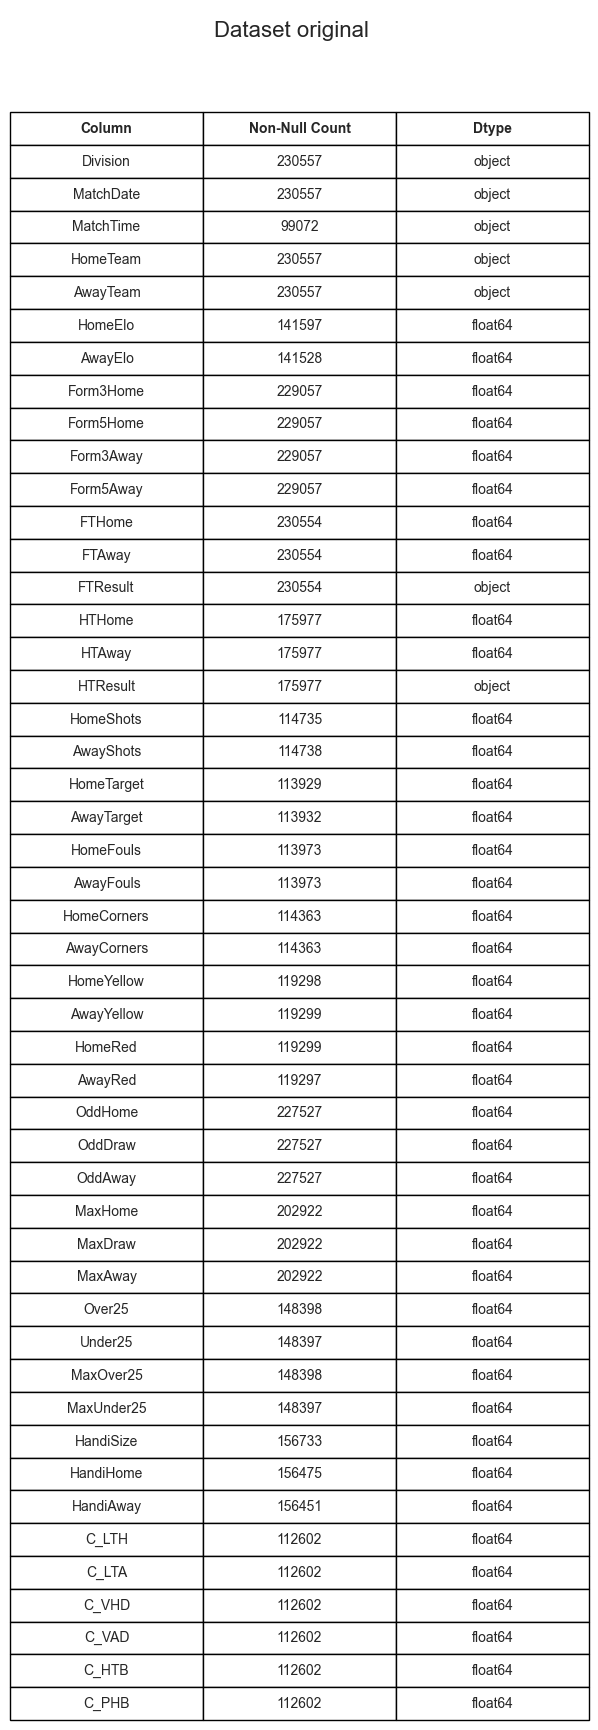

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

info_table1 = pd.DataFrame({
    "Column": matches.columns,
    "Non-Null Count": matches.count().values,
    "Dtype": matches.dtypes.values
})

sns.set_theme(style="white")

n_rows = len(info_table1)

# make figure height depend on number of rows
fig_height = 0.42 * (n_rows + 1) + 0.8

fig, ax = plt.subplots(figsize=(6, fig_height))
ax.axis("off")

table1 = ax.table(
    cellText=info_table1.values,
    colLabels=info_table1.columns,
    cellLoc="center",
    bbox=[0, 0, 1, 0.94],   # fills almost whole axes area
    colWidths=[0.25, 0.25, 0.25]
)

table1.auto_set_font_size(False)
table1.set_fontsize(10)
table1.scale(1, 1.15)

for (row, col), cell in table1.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_linewidth(1)
    cell.set_facecolor("white")

# bold header
for col in range(len(info_table1.columns)):
    table1[(0, col)].set_text_props(weight="bold")

fig.suptitle("Dataset original", fontsize=16, y=0.995)

plt.subplots_adjust(top=1, bottom=0.2, left=0.03, right=0.995)
plt.show()

In [5]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230557 entries, 0 to 230556
Data columns (total 48 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Division     230557 non-null  object 
 1   MatchDate    230557 non-null  object 
 2   MatchTime    99072 non-null   object 
 3   HomeTeam     230557 non-null  object 
 4   AwayTeam     230557 non-null  object 
 5   HomeElo      141597 non-null  float64
 6   AwayElo      141528 non-null  float64
 7   Form3Home    229057 non-null  float64
 8   Form5Home    229057 non-null  float64
 9   Form3Away    229057 non-null  float64
 10  Form5Away    229057 non-null  float64
 11  FTHome       230554 non-null  float64
 12  FTAway       230554 non-null  float64
 13  FTResult     230554 non-null  object 
 14  HTHome       175977 non-null  float64
 15  HTAway       175977 non-null  float64
 16  HTResult     175977 non-null  object 
 17  HomeShots    114735 non-null  float64
 18  AwayShots    114738 non-

DROP COLUMNS AND ROWS(n/a)

In [6]:
matches_cleaned = matches.drop(columns=['MatchTime', 'HomeFouls', 'AwayFouls',
    'HomeYellow', 'AwayYellow', 'HomeRed', 'AwayRed',
    'MaxHome', 'MaxDraw', 'MaxAway',
    'Over25', 'Under25', 'MaxOver25', 'MaxUnder25',
    'HandiSize', 'HandiHome', 'HandiAway',
    'C_LTH', 'C_LTA', 'C_VHD', 'C_VAD',
    'C_HTB', 'C_PHB'
])

matches_cleaned = matches_cleaned.dropna()

FILTER AND REPLACE VALUES

In [7]:
matches_cleaned = matches_cleaned[matches_cleaned['Division'] == 'E0']
matches_cleaned['MatchDate'] = pd.to_datetime(matches_cleaned['MatchDate'])
matches_cleaned = matches_cleaned[matches_cleaned['MatchDate'].dt.year >= 2010]

matches_cleaned[['HomeTeam', 'AwayTeam']] = (
    matches_cleaned[['HomeTeam', 'AwayTeam']]
        .replace({
            "Nott'm Forest": "Nottingham Forest",
            "Nottm Forest": "Nottingham Forest"
        })
)

matches_cleaned['HomePoints'] = matches_cleaned['FTResult'].map({
    'H': 3,
    'D': 1,
    'A': 0
})

matches_cleaned['AwayPoints'] = matches_cleaned['FTResult'].map({
    'H': 0,
    'D': 1,
    'A': 3
})

matches_cleaned['FTResult'] = matches_cleaned['FTResult'].map({
    'H': 0,
    'D': 1,
    'A': 2
})

In [8]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

matches_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5882 entries, 58916 to 230510
Data columns (total 27 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Division     5882 non-null   object        
 1   MatchDate    5882 non-null   datetime64[ns]
 2   HomeTeam     5882 non-null   object        
 3   AwayTeam     5882 non-null   object        
 4   HomeElo      5882 non-null   float64       
 5   AwayElo      5882 non-null   float64       
 6   Form3Home    5882 non-null   float64       
 7   Form5Home    5882 non-null   float64       
 8   Form3Away    5882 non-null   float64       
 9   Form5Away    5882 non-null   float64       
 10  FTHome       5882 non-null   float64       
 11  FTAway       5882 non-null   float64       
 12  FTResult     5882 non-null   int64         
 13  HTHome       5882 non-null   float64       
 14  HTAway       5882 non-null   float64       
 15  HTResult     5882 non-null   object        
 16  HomeS

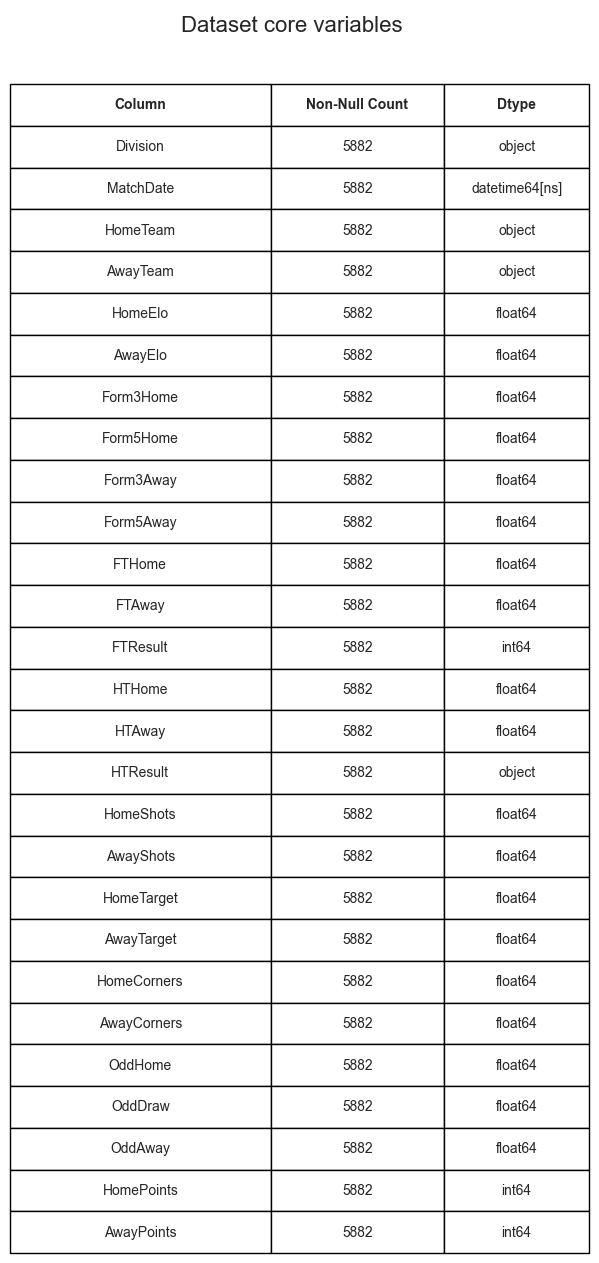

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

info_table2 = pd.DataFrame({
    "Column": matches_cleaned.columns,
    "Non-Null Count": matches_cleaned.count().values,
    "Dtype": matches_cleaned.dtypes.values
})

sns.set_theme(style="white")

n_rows = len(info_table2)

# make figure height depend on number of rows
fig_height = 0.42 * (n_rows + 1) + 0.8

fig, ax = plt.subplots(figsize=(6, fig_height))
ax.axis("off")

table2 = ax.table(
    cellText=info_table2.values,
    colLabels=info_table2.columns,
    cellLoc="center",
    bbox=[0, 0, 1, 0.94],   # fills almost whole axes area
    colWidths=[0.45, 0.30, 0.25]
)

table2.auto_set_font_size(False)
table2.set_fontsize(10)
table2.scale(1, 1.15)

for (row, col), cell in table2.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_linewidth(1)
    cell.set_facecolor("white")

# bold header
for col in range(len(info_table2.columns)):
    table2[(0, col)].set_text_props(weight="bold")

fig.suptitle("Dataset core variables", fontsize=16, y=0.995)

plt.subplots_adjust(top=1, bottom=0.01, left=0.03, right=0.995)
plt.show()

In [10]:
matches_cleaned['margin'] = 1 / matches_cleaned['OddHome'] + 1 / matches_cleaned['OddDraw'] + 1 / matches_cleaned['OddAway']
matches_cleaned['HomeOdds'] = 1 / matches_cleaned['OddHome'] / matches_cleaned['margin']
matches_cleaned['DrawOdds'] = 1 / matches_cleaned['OddDraw'] / matches_cleaned['margin']
matches_cleaned['AwayOdds'] = 1 / matches_cleaned['OddAway'] / matches_cleaned['margin']


In [11]:
matches_cleaned = matches_cleaned.drop(columns=['OddHome', 'OddDraw', 'OddAway', 'margin'])

ROLLING AVERAGES FOR TOTAL POINTS

In [12]:
matches_cleaned['MatchDate'] = pd.to_datetime(matches_cleaned['MatchDate'])

# Sort chronologically and create stable match id
matches_cleaned = matches_cleaned.sort_values('MatchDate').reset_index(drop=True)
matches_cleaned['MatchID'] = matches_cleaned.index

# --- Long format: one row per (match, team) with points earned ---
home_long = matches_cleaned[['MatchID', 'MatchDate', 'HomeTeam', 'HomePoints']].copy()
home_long = home_long.rename(columns={'HomeTeam': 'Team', 'HomePoints': 'Points'})
home_long['Side'] = 'Home'

away_long = matches_cleaned[['MatchID', 'MatchDate', 'AwayTeam', 'AwayPoints']].copy()
away_long = away_long.rename(columns={'AwayTeam': 'Team', 'AwayPoints': 'Points'})
away_long['Side'] = 'Away'

teams_long = pd.concat([home_long, away_long], ignore_index=True)

# --- Rolling average points over last 20 games per team (BEFORE match) ---
teams_long = teams_long.sort_values(['Team', 'MatchDate', 'MatchID']).reset_index(drop=True)

g = teams_long.groupby('Team')['Points']

# rolling avg of previous 20 matches: shift to exclude current match
teams_long['RollingAvgPoints20Before'] = (
    g.apply(lambda s: s.shift(1).rolling(window=20, min_periods=1).mean())
     .reset_index(level=0, drop=True)
)

# --- Merge back to match table as Home/Away features ---
home_feat = teams_long[teams_long['Side'] == 'Home'][['MatchID', 'RollingAvgPoints20Before']].rename(
    columns={'RollingAvgPoints20Before': 'HomeTotalPointsRoll20'}  # name kept, now rolling avg
)
away_feat = teams_long[teams_long['Side'] == 'Away'][['MatchID', 'RollingAvgPoints20Before']].rename(
    columns={'RollingAvgPoints20Before': 'AwayTotalPointsRoll20'}  # name kept, now rolling avg
)

matches_cleaned = matches_cleaned.merge(home_feat, on='MatchID', how='left')
matches_cleaned = matches_cleaned.merge(away_feat, on='MatchID', how='left')

ROLLING AVERAGES FOR HOME POINTS

In [13]:
# Ensure chronological order
matches_cleaned['MatchDate'] = pd.to_datetime(matches_cleaned['MatchDate'])
matches_cleaned = matches_cleaned.sort_values('MatchDate').reset_index(drop=True)

# --- Rolling avg of last 20 HOME matches for each team ---
matches_cleaned['HomeTeamHomePointsRolling20'] = (
    matches_cleaned
    .groupby('HomeTeam')['HomePoints']
    .apply(lambda s: s.shift(1).rolling(window=20, min_periods=1).mean())
    .reset_index(level=0, drop=True)
)

ROLLING AVERAGES FOR AWAY POINTS

In [14]:
matches_cleaned['AwayTeamAwayPointsRolling20'] = (
    matches_cleaned
    .groupby('AwayTeam')['AwayPoints']
    .apply(lambda s: s.shift(1).rolling(window=20, min_periods=1).mean())
    .reset_index(level=0, drop=True)
)

ROLLING AVERAGES FOR TOTAL SHOTS

In [15]:
# Ensure shots are numeric
matches_cleaned['HomeShots'] = pd.to_numeric(matches_cleaned['HomeShots'], errors='coerce')
matches_cleaned['AwayShots'] = pd.to_numeric(matches_cleaned['AwayShots'], errors='coerce')

# --- Long format: one row per (match, team) with shots taken in that match ---
home_long = matches_cleaned[['MatchID', 'MatchDate', 'HomeTeam', 'HomeShots']].copy()
home_long = home_long.rename(columns={'HomeTeam': 'Team', 'HomeShots': 'Shots'})
home_long['Side'] = 'Home'

away_long = matches_cleaned[['MatchID', 'MatchDate', 'AwayTeam', 'AwayShots']].copy()
away_long = away_long.rename(columns={'AwayTeam': 'Team', 'AwayShots': 'Shots'})
away_long['Side'] = 'Away'

teams_long = pd.concat([home_long, away_long], ignore_index=True)

# --- Rolling AVG shots per team over last 20 games (BEFORE match), no seasonality ---
teams_long = teams_long.sort_values(['Team', 'MatchDate', 'MatchID']).reset_index(drop=True)

g = teams_long.groupby('Team')['Shots']

teams_long['ShotsRolling20Before'] = (
    g.apply(lambda s: s.shift(1).rolling(window=20, min_periods=1).mean())
     .reset_index(level=0, drop=True)
)

# --- Merge back to match table as Home/Away features ---
home_feat = teams_long[teams_long['Side'] == 'Home'][['MatchID', 'ShotsRolling20Before']].rename(
    columns={'ShotsRolling20Before': 'HomeTeamShotsRolling20'}
)
away_feat = teams_long[teams_long['Side'] == 'Away'][['MatchID', 'ShotsRolling20Before']].rename(
    columns={'ShotsRolling20Before': 'AwayTeamShotsRolling20'}
)

matches_cleaned = matches_cleaned.merge(home_feat, on='MatchID', how='left')
matches_cleaned = matches_cleaned.merge(away_feat, on='MatchID', how='left')
# Optional cleanup:
# matches_cleaned = matches_cleaned.drop(columns=['MatchID'])

ROLLING AVERAGE FOR HOME AND AWAY SHOTS

In [16]:
# Ensure datetime + chronological order
matches_cleaned['MatchDate'] = pd.to_datetime(matches_cleaned['MatchDate'])
matches_cleaned = matches_cleaned.sort_values('MatchDate').reset_index(drop=True)

# Shots numeric
matches_cleaned['HomeShots'] = pd.to_numeric(matches_cleaned['HomeShots'], errors='coerce')
matches_cleaned['AwayShots'] = pd.to_numeric(matches_cleaned['AwayShots'], errors='coerce')

# --- Home team: rolling avg of last 20 HOME matches (exclude current) ---
matches_cleaned['HomeTeamShotsHomeRolling20'] = (
    matches_cleaned
    .groupby('HomeTeam')['HomeShots']
    .apply(lambda s: s.shift(1).rolling(window=20, min_periods=1).mean())
    .reset_index(level=0, drop=True)
)

# --- Away team: rolling avg of last 20 AWAY matches (exclude current) ---
matches_cleaned['AwayTeamShotsAwayRolling20'] = (
    matches_cleaned
    .groupby('AwayTeam')['AwayShots']
    .apply(lambda s: s.shift(1).rolling(window=20, min_periods=1).mean())
    .reset_index(level=0, drop=True)
)

# Optional: fill early NaNs (teams with no prior home/away games)
# matches_cleaned[['HomeTeamShotsHomeRolling20', 'AwayTeamShotsAwayRolling20']] = (
#     matches_cleaned[['HomeTeamShotsHomeRolling20', 'AwayTeamShotsAwayRolling20']].fillna(0)
# )

ROLLING AVERAGE FOR SHOTS ON TARGET

In [17]:
# Ensure numeric
matches_cleaned['HomeTarget'] = pd.to_numeric(matches_cleaned['HomeTarget'], errors='coerce')
matches_cleaned['AwayTarget'] = pd.to_numeric(matches_cleaned['AwayTarget'], errors='coerce')

# Make sure sorted and MatchID exists
matches_cleaned['MatchDate'] = pd.to_datetime(matches_cleaned['MatchDate'])
matches_cleaned = matches_cleaned.sort_values('MatchDate').reset_index(drop=True)
if 'MatchID' not in matches_cleaned.columns:
    matches_cleaned['MatchID'] = matches_cleaned.index

# --- Long format ---
home_long = matches_cleaned[['MatchID','MatchDate','HomeTeam','HomeTarget']].copy()
home_long = home_long.rename(columns={'HomeTeam':'Team','HomeTarget':'TargetShots'})
home_long['Side'] = 'Home'

away_long = matches_cleaned[['MatchID','MatchDate','AwayTeam','AwayTarget']].copy()
away_long = away_long.rename(columns={'AwayTeam':'Team','AwayTarget':'TargetShots'})
away_long['Side'] = 'Away'

teams_long = pd.concat([home_long, away_long], ignore_index=True)

# --- Rolling AVG per team over last 20 matches (BEFORE match), no seasonality ---
teams_long = teams_long.sort_values(['Team','MatchDate','MatchID']).reset_index(drop=True)

g = teams_long.groupby('Team')['TargetShots']

teams_long['TargetShotsRolling20Before'] = (
    g.apply(lambda s: s.shift(1).rolling(window=20, min_periods=1).mean())
     .reset_index(level=0, drop=True)
)

# --- Merge back ---
home_feat = teams_long[teams_long['Side']=='Home'][['MatchID','TargetShotsRolling20Before']] \
    .rename(columns={'TargetShotsRolling20Before':'HomeTeamTargetShotsRolling20'})

away_feat = teams_long[teams_long['Side']=='Away'][['MatchID','TargetShotsRolling20Before']] \
    .rename(columns={'TargetShotsRolling20Before':'AwayTeamTargetShotsRolling20'})

matches_cleaned = matches_cleaned.merge(home_feat, on='MatchID', how='left')
matches_cleaned = matches_cleaned.merge(away_feat, on='MatchID', how='left')

ROLLING AVERAGE TOTAL GOALS HOME AND AWAY TEAM

In [18]:
# Ensure numeric
matches_cleaned['FTHome'] = pd.to_numeric(matches_cleaned['FTHome'], errors='coerce')
matches_cleaned['FTAway'] = pd.to_numeric(matches_cleaned['FTAway'], errors='coerce')

# --- Long format: goals scored by each team in each match ---
home_long = matches_cleaned[['MatchID', 'MatchDate', 'HomeTeam', 'FTHome']].copy()
home_long = home_long.rename(columns={'HomeTeam': 'Team', 'FTHome': 'Goals'})
home_long['Side'] = 'Home'

away_long = matches_cleaned[['MatchID', 'MatchDate', 'AwayTeam', 'FTAway']].copy()
away_long = away_long.rename(columns={'AwayTeam': 'Team', 'FTAway': 'Goals'})
away_long['Side'] = 'Away'

teams_long = pd.concat([home_long, away_long], ignore_index=True)

# --- Rolling AVG goals per team over last 20 matches (BEFORE match), no seasonality ---
teams_long = teams_long.sort_values(['Team', 'MatchDate', 'MatchID']).reset_index(drop=True)

g = teams_long.groupby('Team')['Goals']

teams_long['GoalsRolling20Before'] = (
    g.apply(lambda s: s.shift(1).rolling(window=20, min_periods=1).mean())
     .reset_index(level=0, drop=True)
)

# --- Merge back to match table ---
home_feat = teams_long[teams_long['Side'] == 'Home'][['MatchID', 'GoalsRolling20Before']].rename(
    columns={'GoalsRolling20Before': 'HomeTotalGoalsRolling20'}
)
away_feat = teams_long[teams_long['Side'] == 'Away'][['MatchID', 'GoalsRolling20Before']].rename(
    columns={'GoalsRolling20Before': 'AwayTotalGoalsRolling20'}
)

matches_cleaned = matches_cleaned.merge(home_feat, on='MatchID', how='left')
matches_cleaned = matches_cleaned.merge(away_feat, on='MatchID', how='left')

ROLLING AVERAGES GOALS HOME AND AWAY

In [19]:
# Ensure numeric
matches_cleaned['FTHome'] = pd.to_numeric(matches_cleaned['FTHome'], errors='coerce')
matches_cleaned['FTAway'] = pd.to_numeric(matches_cleaned['FTAway'], errors='coerce')

# --- Home team: rolling avg goals in last 20 HOME matches (exclude current) ---
matches_cleaned['HomeGoalsHomeRolling20'] = (
    matches_cleaned
    .groupby('HomeTeam')['FTHome']
    .apply(lambda s: s.shift(1).rolling(window=20, min_periods=1).mean())
    .reset_index(level=0, drop=True)
)

# --- Away team: rolling avg goals in last 20 AWAY matches (exclude current) ---
matches_cleaned['AwayGoalsAwayRolling20'] = (
    matches_cleaned
    .groupby('AwayTeam')['FTAway']
    .apply(lambda s: s.shift(1).rolling(window=20, min_periods=1).mean())
    .reset_index(level=0, drop=True)
)

# Optional: fill early NaNs
# matches_cleaned[['HomeGoalsHomeRolling20','AwayGoalsAwayRolling20']] = (
#     matches_cleaned[['HomeGoalsHomeRolling20','AwayGoalsAwayRolling20']].fillna(0)
# )

ROLLING AVERAGE GOALS CONCEDED HOME AND AWAY FOR HOME AND AWAY TEAM

In [20]:
# Ensure numeric
matches_cleaned['FTHome'] = pd.to_numeric(matches_cleaned['FTHome'], errors='coerce')
matches_cleaned['FTAway'] = pd.to_numeric(matches_cleaned['FTAway'], errors='coerce')

# --- Home team conceded at home: rolling avg conceded in last 20 HOME matches (exclude current) ---
matches_cleaned['HomeConcededHomeRolling20'] = (
    matches_cleaned
    .groupby('HomeTeam')['FTAway']
    .apply(lambda s: s.shift(1).rolling(window=20, min_periods=1).mean())
    .reset_index(level=0, drop=True)
)

# --- Away team conceded away: rolling avg conceded in last 20 AWAY matches (exclude current) ---
matches_cleaned['AwayConcededAwayRolling20'] = (
    matches_cleaned
    .groupby('AwayTeam')['FTHome']
    .apply(lambda s: s.shift(1).rolling(window=20, min_periods=1).mean())
    .reset_index(level=0, drop=True)
)


In [21]:
matches_features = matches_cleaned[['HomeElo', 'AwayElo', 
    'Form3Home', 'Form5Home', 'Form3Away', 'Form5Away', 
    'FTResult', 
    'HomeTotalPointsRoll20', 'AwayTotalPointsRoll20',
    'HomeTeamHomePointsRolling20', 'AwayTeamAwayPointsRolling20', 
    'HomeTeamShotsRolling20', 'AwayTeamShotsRolling20', 
    'HomeTeamShotsHomeRolling20', 'AwayTeamShotsAwayRolling20', 
    'HomeTeamTargetShotsRolling20', 'AwayTeamTargetShotsRolling20', 
    'HomeTotalGoalsRolling20', 'AwayTotalGoalsRolling20', 
    'HomeGoalsHomeRolling20', 'AwayGoalsAwayRolling20', 
    'HomeConcededHomeRolling20','AwayConcededAwayRolling20', 'HomeOdds', 'DrawOdds', 'AwayOdds']]

In [22]:
matches_features

,HomeElo,AwayElo,Form3Home,Form5Home,Form3Away,Form5Away,FTResult,HomeTotalPointsRoll20,AwayTotalPointsRoll20,HomeTeamHomePointsRolling20,AwayTeamAwayPointsRolling20,HomeTeamShotsRolling20,AwayTeamShotsRolling20,HomeTeamShotsHomeRolling20,AwayTeamShotsAwayRolling20,HomeTeamTargetShotsRolling20,AwayTeamTargetShotsRolling20,HomeTotalGoalsRolling20,AwayTotalGoalsRolling20,HomeGoalsHomeRolling20,AwayGoalsAwayRolling20,HomeConcededHomeRolling20,AwayConcededAwayRolling20,HomeOdds,DrawOdds,AwayOdds
0,1621.51,1737.53,0.0,1.0,4.0,8.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.361586,0.292606,0.345808
1,1883.65,1708.42,9.0,13.0,5.0,7.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.677591,0.210806,0.111603
2,1653.17,1930.65,5.0,11.0,6.0,9.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.146673,0.264826,0.588502
3,1745.52,1642.07,9.0,10.0,2.0,3.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.661129,0.219867,0.119003
4,1947.83,1609.25,5.0,9.0,2.0,3.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.778412,0.158277,0.063311
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5877,1799.76,1880.42,5.0,8.0,6.0,12.0,2,1.70,1.55,1.50,1.55,11.65,16.05,13.30,13.80,4.3,5.55,1.80,1.30,1.45,1.65,1.10,1.40,0.309101,0.256753,0.434146
5878,1557.66,1985.45,1.0,2.0,4.0,8.0,2,0.30,1.90,0.35,1.90,9.10,14.15,8.80,11.90,3.0,4.55,0.70,1.65,0.80,1.80,2.55,0.90,0.100538,0.162964,0.736498
5879,1882.33,1776.20,4.0,7.0,7.0,7.0,2,2.00,1.45,2.10,1.10,13.75,9.65,15.85,9.70,4.7,3.90,2.05,1.35,2.30,0.85,1.05,1.20,0.721382,0.170040,0.108578
5880,2008.67,1820.28,1.0,7.0,7.0,9.0,1,2.05,1.80,2.55,1.55,17.95,13.40,18.05,13.15,5.8,5.00,2.25,1.60,2.35,1.50,0.85,1.30,0.679776,0.168440,0.151784


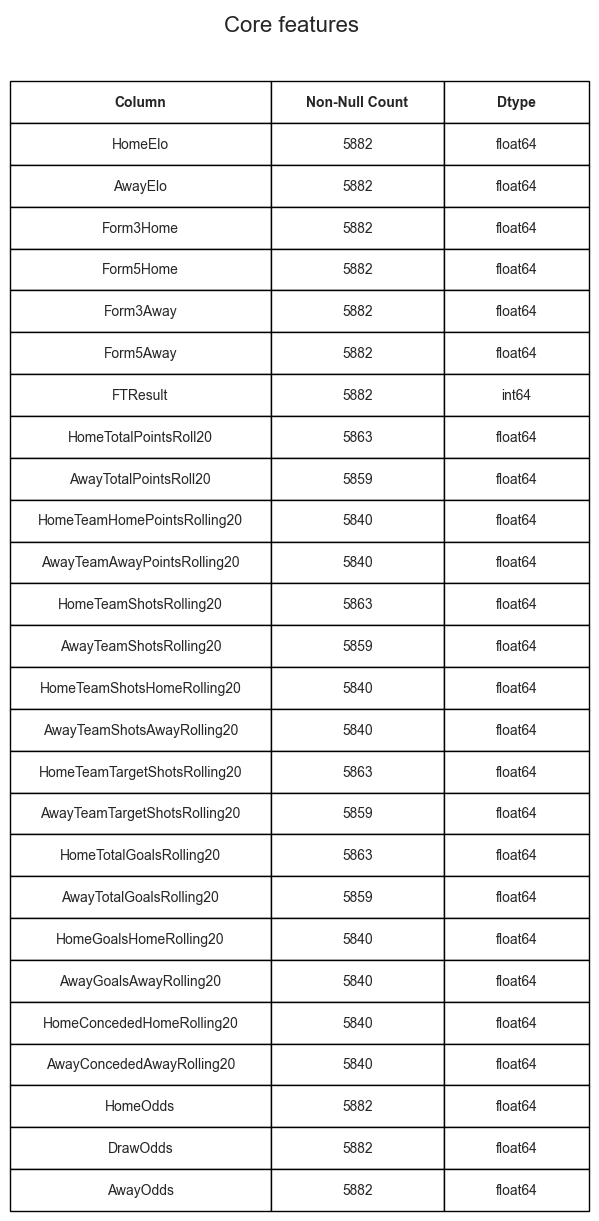

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

info_table3 = pd.DataFrame({
    "Column": matches_features.columns,
    "Non-Null Count": matches_features.count().values,
    "Dtype": matches_features.dtypes.values
})

sns.set_theme(style="white")

n_rows = len(info_table3)

# make figure height depend on number of rows
fig_height = 0.42 * (n_rows + 1) + 0.8

fig, ax = plt.subplots(figsize=(6, fig_height))
ax.axis("off")

table3 = ax.table(
    cellText=info_table3.values,
    colLabels=info_table3.columns,
    cellLoc="center",
    bbox=[0, 0, 1, 0.94],   # fills almost whole axes area
    colWidths=[0.45, 0.30, 0.25]
)

table3.auto_set_font_size(False)
table3.set_fontsize(10)
table3.scale(1, 1.15)

for (row, col), cell in table3.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_linewidth(1)
    cell.set_facecolor("white")

# bold header
for col in range(len(info_table3.columns)):
    table3[(0, col)].set_text_props(weight="bold")

fig.suptitle("Core features", fontsize=16, y=0.995)

plt.subplots_adjust(top=1, bottom=0.01, left=0.03, right=0.995)
plt.show()

DIFFERENCE FEATURES

In [24]:
matches_features['TotalPointsRoll20_diff'] = matches_features['AwayTotalPointsRoll20'] - matches_features['HomeTotalPointsRoll20']

matches_features['HomeAwayPointsRolling20_diff'] = matches_features['AwayTeamAwayPointsRolling20'] - matches_features['HomeTeamHomePointsRolling20']

matches_features['ShotsRolling20_diff'] = matches_features['AwayTeamShotsRolling20'] - matches_features['HomeTeamShotsRolling20']

matches_features['ShotsHomeAwayRolling20_diff'] = matches_features['AwayTeamShotsAwayRolling20'] - matches_features['HomeTeamShotsHomeRolling20']

matches_features['TargetShotsRolling20_diff'] = matches_features['AwayTeamTargetShotsRolling20'] - matches_features['HomeTeamTargetShotsRolling20']

matches_features['GoalsRolling20_diff'] = matches_features['AwayTotalGoalsRolling20'] - matches_features['HomeTotalGoalsRolling20']

matches_features['GoalsHomeAwayRolling20_diff'] = matches_features['AwayGoalsAwayRolling20'] - matches_features['HomeGoalsHomeRolling20']

matches_features['ConcededHomeAwayRolling20_diff'] = matches_features['AwayConcededAwayRolling20'] - matches_features['HomeConcededHomeRolling20']


C:\Users\mikko\AppData\Local\Temp\ipykernel_2828\991253460.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matches_features['TotalPointsRoll20_diff'] = matches_features['AwayTotalPointsRoll20'] - matches_features['HomeTotalPointsRoll20']
C:\Users\mikko\AppData\Local\Temp\ipykernel_2828\991253460.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matches_features['HomeAwayPointsRolling20_diff'] = matches_features['AwayTeamAwayPointsRolling20'] - matches_features['HomeTeamHomePointsRolling20']
C:\Users\m

INTEGERS

In [25]:
int_cols = ['Form3Home', 'Form5Home', 'Form3Away', 'Form5Away', 'FTResult']

# convert specific columns to int
matches_features[int_cols] = matches_features[int_cols].astype('int64')

# convert the rest to float
matches_features.loc[:, ~matches_features.columns.isin(int_cols)] = matches_features.loc[:, ~matches_features.columns.isin(int_cols)].astype('float64')

C:\Users\mikko\AppData\Local\Temp\ipykernel_2828\442490929.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matches_features[int_cols] = matches_features[int_cols].astype('int64')


FEATURES AND TARGET (X, y)

In [26]:
matches_features = matches_features.dropna()

X = matches_features.drop(['FTResult', 'HomeOdds', 'DrawOdds', 'AwayOdds'], axis=1)
y = matches_features['FTResult']

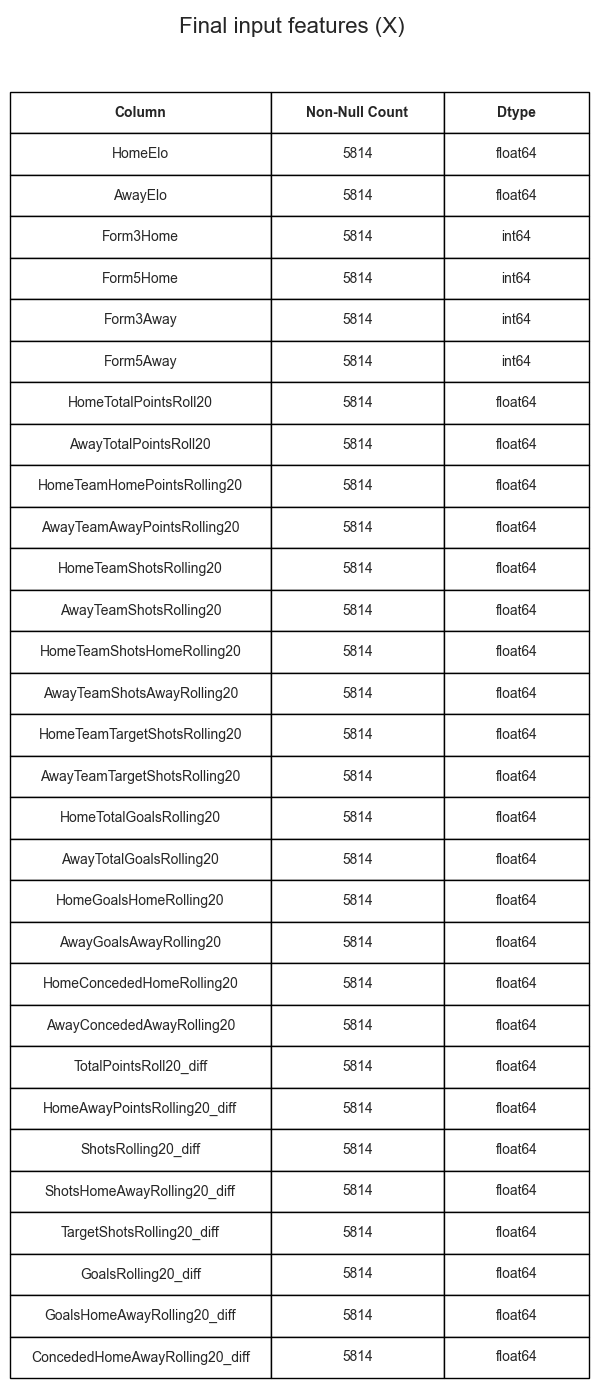

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

info_table4 = pd.DataFrame({
    "Column": X.columns,
    "Non-Null Count": X.count().values,
    "Dtype": X.dtypes.values
})

sns.set_theme(style="white")

n_rows = len(info_table4)

# make figure height depend on number of rows
fig_height = 0.42 * (n_rows + 1) + 0.8

fig, ax = plt.subplots(figsize=(6, fig_height))
ax.axis("off")

table4 = ax.table(
    cellText=info_table4.values,
    colLabels=info_table4.columns,
    cellLoc="center",
    bbox=[0, 0, 1, 0.94],   # fills almost whole axes area
    colWidths=[0.45, 0.30, 0.25]
)

table4.auto_set_font_size(False)
table4.set_fontsize(10)
table4.scale(1, 1.15)

for (row, col), cell in table4.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_linewidth(1)
    cell.set_facecolor("white")

# bold header
for col in range(len(info_table4.columns)):
    table4[(0, col)].set_text_props(weight="bold")

fig.suptitle("Final input features (X)", fontsize=16, y=0.995)

plt.subplots_adjust(top=1, bottom=0.01, left=0.03, right=0.995)
plt.show()

In [28]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5814 entries, 15 to 5881
Data columns (total 30 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   HomeElo                         5814 non-null   float64
 1   AwayElo                         5814 non-null   float64
 2   Form3Home                       5814 non-null   int64  
 3   Form5Home                       5814 non-null   int64  
 4   Form3Away                       5814 non-null   int64  
 5   Form5Away                       5814 non-null   int64  
 6   HomeTotalPointsRoll20           5814 non-null   float64
 7   AwayTotalPointsRoll20           5814 non-null   float64
 8   HomeTeamHomePointsRolling20     5814 non-null   float64
 9   AwayTeamAwayPointsRolling20     5814 non-null   float64
 10  HomeTeamShotsRolling20          5814 non-null   float64
 11  AwayTeamShotsRolling20          5814 non-null   float64
 12  HomeTeamShotsHomeRolling20      5814 n

TRAIN AND TEST DATA SPLIT

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

RANDOM FOREST TRAINING

In [61]:
rf = RandomForestClassifier(
    n_estimators=1500,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced_subsample", 
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

# Predict class + probabilities
pred_rf = rf.predict(X_test)
proba_rf = rf.predict_proba(X_test)

print("Accuracy:", accuracy_score(y_test, pred_rf))
print("LogLoss:", log_loss(y_test, proba_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred_rf))

Accuracy: 0.532244196044712
LogLoss: 0.9806922330761814

Confusion Matrix:
 [[363  36 123]
 [129  21 119]
 [108  29 235]]


In [63]:
print("\nClassification Report:\n", classification_report(y_test, pred_rf, digits=2))


Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.70      0.65       522
           1       0.24      0.08      0.12       269
           2       0.49      0.63      0.55       372

    accuracy                           0.53      1163
   macro avg       0.45      0.47      0.44      1163
weighted avg       0.49      0.53      0.49      1163



In [59]:
imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(imp.head(10))

ShotsRolling20_diff             0.052421
TargetShotsRolling20_diff       0.050427
ShotsHomeAwayRolling20_diff     0.049747
HomeElo                         0.047269
AwayElo                         0.046196
GoalsRolling20_diff             0.041478
TotalPointsRoll20_diff          0.041459
HomeAwayPointsRolling20_diff    0.041277
GoalsHomeAwayRolling20_diff     0.040038
AwayTeamShotsRolling20          0.037668
dtype: float64


In [32]:
X_rf_last = X_test.iloc[[-1]]   # double brackets keep it 2D

pred_rf_last = rf.predict(X_rf_last)
proba_rf_last = rf.predict_proba(X_rf_last)

print("Predicted class:", pred_rf_last)
print("Probabilities:", proba_rf_last)

Predicted class: [2]
Probabilities: [[0.25985616 0.32988926 0.41025459]]


In [ ]:
pred_y_rf = rf.predict(X_test)
proba_rf = rf.predict_proba(X_test)
proba_rf_df = pd.DataFrame(proba_rf, columns=['pred_rf_H', 'pred_rf_D', 'pred_rf_A'])

,pred_rf_H,pred_rf_D,pred_rf_A
0,0.492086,0.289211,0.218703
1,0.234019,0.230213,0.535767
2,0.764973,0.085060,0.149967
3,0.150047,0.192955,0.656998
4,0.151864,0.182363,0.665773
...,...,...,...
1158,0.235876,0.253295,0.510829
1159,0.128058,0.238136,0.633806
1160,0.574948,0.254630,0.170423
1161,0.654140,0.195140,0.150720


In [34]:
Features_odds = matches_features.iloc[-len(proba_rf_df):][['HomeOdds','DrawOdds','AwayOdds']].reset_index(drop=True)

proba_rf_df = pd.concat([proba_rf_df.reset_index(drop=True), Features_odds], axis=1)

In [35]:
proba_rf_df['total_prob'] = proba_rf_df['HomeOdds'] + proba_rf_df['DrawOdds'] + proba_rf_df['AwayOdds']
proba_rf_df

,pred_rf_H,pred_rf_D,pred_rf_A,HomeOdds,DrawOdds,AwayOdds,total_prob
0,0.492086,0.289211,0.218703,0.368517,0.287973,0.343510,1.0
1,0.234019,0.230213,0.535767,0.213252,0.252432,0.534315,1.0
2,0.764973,0.085060,0.149967,0.817383,0.126410,0.056207,1.0
3,0.150047,0.192955,0.656998,0.131240,0.198889,0.669871,1.0
4,0.151864,0.182363,0.665773,0.193189,0.230715,0.576096,1.0
...,...,...,...,...,...,...,...
1158,0.235876,0.253295,0.510829,0.309101,0.256753,0.434146,1.0
1159,0.128058,0.238136,0.633806,0.100538,0.162964,0.736498,1.0
1160,0.574948,0.254630,0.170423,0.721382,0.170040,0.108578,1.0
1161,0.654140,0.195140,0.150720,0.679776,0.168440,0.151784,1.0


In [36]:
proba_rf_rng = rf.predict_proba(X_test)

rng = np.random.default_rng(42)

pred_rf_rng = np.array([
    rng.choice(len(p), p=p) for p in proba_rf_rng
])

In [65]:
print("Accuracy:", accuracy_score(y_test, pred_rf_rng))
print("LogLoss:", log_loss(y_test, proba_rf_rng))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred_rf_rng))

Accuracy: 0.410146173688736
LogLoss: 0.9806922330761814

Confusion Matrix:
 [[253 142 127]
 [ 93  72 104]
 [123  97 152]]


In [64]:
print("\nClassification Report:\n", classification_report(y_test, pred_rf_rng, digits=3))


Classification Report:
               precision    recall  f1-score   support

           0      0.539     0.485     0.511       522
           1      0.232     0.268     0.248       269
           2      0.397     0.409     0.403       372

    accuracy                          0.410      1163
   macro avg      0.389     0.387     0.387      1163
weighted avg      0.423     0.410     0.415      1163



In [38]:

SEED = 42

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 400, 2500),
        "max_depth": trial.suggest_int("max_depth", 4, 60),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 40),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 25),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced", "balanced_subsample"]),
        "n_jobs": -1,
        "random_state": SEED,
    }

    model_rf = RandomForestClassifier(**params)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

    # Optimize for probability quality (lower log loss is better)
    scores = cross_val_score(
        model_rf,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_log_loss",
        n_jobs=-1
    )

    return float(np.mean(scores))  # maximize neg_log_loss

# Study
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED)
)

study.optimize(objective, n_trials=60, show_progress_bar=True)

print("\nBest CV neg_log_loss:", study.best_value)
print("Best params:\n", study.best_params)

# Train final model with best params
rf_opt = RandomForestClassifier(
    **study.best_params,
    n_jobs=-1,
    random_state=SEED
)
rf_opt.fit(X_train, y_train)

[I 2026-03-19 12:50:46,740] A new study created in memory with name: no-name-c63c74aa-7fef-427d-b791-28b31e7eda9d


Best trial: 0. Best value: -1.00061:   2%|▏         | 1/60 [00:16<16:08, 16.42s/it]

[I 2026-03-19 12:51:03,163] Trial 0 finished with value: -1.0006148814645353 and parameters: {'n_estimators': 1186, 'max_depth': 58, 'min_samples_split': 30, 'min_samples_leaf': 15, 'max_features': 'sqrt', 'bootstrap': True, 'class_weight': 'balanced_subsample'}. Best is trial 0 with value: -1.0006148814645353.


Best trial: 0. Best value: -1.00061:   3%|▎         | 2/60 [00:43<21:39, 22.40s/it]

[I 2026-03-19 12:51:29,752] Trial 1 finished with value: -1.0008065043399872 and parameters: {'n_estimators': 2148, 'max_depth': 16, 'min_samples_split': 9, 'min_samples_leaf': 5, 'max_features': 'log2', 'bootstrap': False, 'class_weight': 'balanced_subsample'}. Best is trial 0 with value: -1.0006148814645353.


Best trial: 0. Best value: -1.00061:   5%|▌         | 3/60 [01:22<28:48, 30.33s/it]

[I 2026-03-19 12:52:09,509] Trial 2 finished with value: -1.0022536397165624 and parameters: {'n_estimators': 1358, 'max_depth': 48, 'min_samples_split': 9, 'min_samples_leaf': 13, 'max_features': None, 'bootstrap': True, 'class_weight': 'balanced'}. Best is trial 0 with value: -1.0006148814645353.


Best trial: 3. Best value: -0.979533:   7%|▋         | 4/60 [01:33<21:15, 22.77s/it]

[I 2026-03-19 12:52:20,701] Trial 3 finished with value: -0.9795332259547183 and parameters: {'n_estimators': 1039, 'max_depth': 9, 'min_samples_split': 28, 'min_samples_leaf': 12, 'max_features': 'log2', 'bootstrap': True, 'class_weight': None}. Best is trial 3 with value: -0.9795332259547183.


Best trial: 3. Best value: -0.979533:   8%|▊         | 5/60 [01:47<17:49, 19.45s/it]

[I 2026-03-19 12:52:34,257] Trial 4 finished with value: -1.0015373793542686 and parameters: {'n_estimators': 1548, 'max_depth': 14, 'min_samples_split': 39, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'bootstrap': True, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: -0.9795332259547183.


Best trial: 3. Best value: -0.979533:  10%|█         | 6/60 [01:56<14:11, 15.76s/it]

[I 2026-03-19 12:52:42,869] Trial 5 finished with value: -0.9807291906315367 and parameters: {'n_estimators': 1216, 'max_depth': 19, 'min_samples_split': 34, 'min_samples_leaf': 9, 'max_features': 'log2', 'bootstrap': True, 'class_weight': None}. Best is trial 3 with value: -0.9795332259547183.


Best trial: 3. Best value: -0.979533:  12%|█▏        | 7/60 [02:00<10:36, 12.01s/it]

[I 2026-03-19 12:52:47,140] Trial 6 finished with value: -0.9824736019562096 and parameters: {'n_estimators': 411, 'max_depth': 50, 'min_samples_split': 29, 'min_samples_leaf': 19, 'max_features': 'sqrt', 'bootstrap': False, 'class_weight': None}. Best is trial 3 with value: -0.9795332259547183.


Best trial: 3. Best value: -0.979533:  13%|█▎        | 8/60 [02:10<10:01, 11.56s/it]

[I 2026-03-19 12:52:57,735] Trial 7 finished with value: -1.0055086956092765 and parameters: {'n_estimators': 1053, 'max_depth': 22, 'min_samples_split': 30, 'min_samples_leaf': 16, 'max_features': 'sqrt', 'bootstrap': False, 'class_weight': 'balanced'}. Best is trial 3 with value: -0.9795332259547183.


Best trial: 3. Best value: -0.979533:  15%|█▌        | 9/60 [02:28<11:18, 13.31s/it]

[I 2026-03-19 12:53:14,894] Trial 8 finished with value: -0.9999161662152748 and parameters: {'n_estimators': 1498, 'max_depth': 28, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'log2', 'bootstrap': False, 'class_weight': 'balanced_subsample'}. Best is trial 3 with value: -0.9795332259547183.


Best trial: 3. Best value: -0.979533:  17%|█▋        | 10/60 [02:33<09:09, 10.98s/it]

[I 2026-03-19 12:53:20,664] Trial 9 finished with value: -1.0003684823565195 and parameters: {'n_estimators': 880, 'max_depth': 8, 'min_samples_split': 13, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': True, 'class_weight': 'balanced'}. Best is trial 3 with value: -0.9795332259547183.


Best trial: 10. Best value: -0.97862:  18%|█▊        | 11/60 [02:59<12:37, 15.47s/it]

[I 2026-03-19 12:53:46,304] Trial 10 finished with value: -0.9786198515093503 and parameters: {'n_estimators': 2032, 'max_depth': 4, 'min_samples_split': 21, 'min_samples_leaf': 24, 'max_features': None, 'bootstrap': True, 'class_weight': None}. Best is trial 10 with value: -0.9786198515093503.


Best trial: 10. Best value: -0.97862:  20%|██        | 12/60 [03:36<17:38, 22.05s/it]

[I 2026-03-19 12:54:23,420] Trial 11 finished with value: -0.9791666649262698 and parameters: {'n_estimators': 2413, 'max_depth': 5, 'min_samples_split': 22, 'min_samples_leaf': 25, 'max_features': None, 'bootstrap': True, 'class_weight': None}. Best is trial 10 with value: -0.9786198515093503.


Best trial: 10. Best value: -0.97862:  22%|██▏       | 13/60 [04:15<21:16, 27.15s/it]

[I 2026-03-19 12:55:02,310] Trial 12 finished with value: -0.9791311517329667 and parameters: {'n_estimators': 2485, 'max_depth': 5, 'min_samples_split': 20, 'min_samples_leaf': 25, 'max_features': None, 'bootstrap': True, 'class_weight': None}. Best is trial 10 with value: -0.9786198515093503.


Best trial: 10. Best value: -0.97862:  23%|██▎       | 14/60 [04:57<24:13, 31.59s/it]

[I 2026-03-19 12:55:44,146] Trial 13 finished with value: -0.9822181371435516 and parameters: {'n_estimators': 1925, 'max_depth': 38, 'min_samples_split': 20, 'min_samples_leaf': 25, 'max_features': None, 'bootstrap': True, 'class_weight': None}. Best is trial 10 with value: -0.9786198515093503.


Best trial: 10. Best value: -0.97862:  25%|██▌       | 15/60 [05:30<24:07, 32.16s/it]

[I 2026-03-19 12:56:17,637] Trial 14 finished with value: -0.9786715789590973 and parameters: {'n_estimators': 2481, 'max_depth': 4, 'min_samples_split': 19, 'min_samples_leaf': 21, 'max_features': None, 'bootstrap': True, 'class_weight': None}. Best is trial 10 with value: -0.9786198515093503.


Best trial: 10. Best value: -0.97862:  27%|██▋       | 16/60 [06:13<25:51, 35.26s/it]

[I 2026-03-19 12:57:00,088] Trial 15 finished with value: -0.9831431078572594 and parameters: {'n_estimators': 1890, 'max_depth': 32, 'min_samples_split': 15, 'min_samples_leaf': 21, 'max_features': None, 'bootstrap': True, 'class_weight': None}. Best is trial 10 with value: -0.9786198515093503.


Best trial: 10. Best value: -0.97862:  28%|██▊       | 17/60 [07:00<27:56, 38.98s/it]

[I 2026-03-19 12:57:47,738] Trial 16 finished with value: -0.9830726610841282 and parameters: {'n_estimators': 2175, 'max_depth': 25, 'min_samples_split': 16, 'min_samples_leaf': 22, 'max_features': None, 'bootstrap': True, 'class_weight': None}. Best is trial 10 with value: -0.9786198515093503.


Best trial: 10. Best value: -0.97862:  30%|███       | 18/60 [07:44<28:08, 40.20s/it]

[I 2026-03-19 12:58:30,767] Trial 17 finished with value: -0.9840475130050997 and parameters: {'n_estimators': 1795, 'max_depth': 13, 'min_samples_split': 25, 'min_samples_leaf': 17, 'max_features': None, 'bootstrap': True, 'class_weight': None}. Best is trial 10 with value: -0.9786198515093503.


Best trial: 10. Best value: -0.97862:  32%|███▏      | 19/60 [09:01<35:10, 51.49s/it]

[I 2026-03-19 12:59:48,541] Trial 18 finished with value: -1.8854534007786998 and parameters: {'n_estimators': 2208, 'max_depth': 39, 'min_samples_split': 24, 'min_samples_leaf': 22, 'max_features': None, 'bootstrap': False, 'class_weight': None}. Best is trial 10 with value: -0.9786198515093503.


Best trial: 10. Best value: -0.97862:  33%|███▎      | 20/60 [09:24<28:32, 42.82s/it]

[I 2026-03-19 13:00:11,176] Trial 19 finished with value: -1.0071184019499235 and parameters: {'n_estimators': 1752, 'max_depth': 4, 'min_samples_split': 18, 'min_samples_leaf': 18, 'max_features': None, 'bootstrap': True, 'class_weight': 'balanced'}. Best is trial 10 with value: -0.9786198515093503.


Best trial: 10. Best value: -0.97862:  35%|███▌      | 21/60 [10:26<31:34, 48.58s/it]

[I 2026-03-19 13:01:13,185] Trial 20 finished with value: -0.9863814706069738 and parameters: {'n_estimators': 2301, 'max_depth': 12, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': None, 'bootstrap': True, 'class_weight': None}. Best is trial 10 with value: -0.9786198515093503.


Best trial: 10. Best value: -0.97862:  37%|███▋      | 22/60 [10:58<27:35, 43.57s/it]

[I 2026-03-19 13:01:45,053] Trial 21 finished with value: -0.9786236080680304 and parameters: {'n_estimators': 2483, 'max_depth': 4, 'min_samples_split': 20, 'min_samples_leaf': 24, 'max_features': None, 'bootstrap': True, 'class_weight': None}. Best is trial 10 with value: -0.9786198515093503.


Best trial: 10. Best value: -0.97862:  38%|███▊      | 23/60 [11:41<26:42, 43.32s/it]

[I 2026-03-19 13:02:27,809] Trial 22 finished with value: -0.9821726070204335 and parameters: {'n_estimators': 2034, 'max_depth': 9, 'min_samples_split': 23, 'min_samples_leaf': 23, 'max_features': None, 'bootstrap': True, 'class_weight': None}. Best is trial 10 with value: -0.9786198515093503.


Best trial: 10. Best value: -0.97862:  40%|████      | 24/60 [12:34<27:46, 46.28s/it]

[I 2026-03-19 13:03:21,000] Trial 23 finished with value: -0.9828223299148668 and parameters: {'n_estimators': 2484, 'max_depth': 19, 'min_samples_split': 18, 'min_samples_leaf': 23, 'max_features': None, 'bootstrap': True, 'class_weight': None}. Best is trial 10 with value: -0.9786198515093503.


Best trial: 10. Best value: -0.97862:  42%|████▏     | 25/60 [13:03<24:06, 41.32s/it]

[I 2026-03-19 13:03:50,740] Trial 24 finished with value: -0.978703186873657 and parameters: {'n_estimators': 2345, 'max_depth': 4, 'min_samples_split': 13, 'min_samples_leaf': 20, 'max_features': None, 'bootstrap': True, 'class_weight': None}. Best is trial 10 with value: -0.9786198515093503.


Best trial: 10. Best value: -0.97862:  43%|████▎     | 26/60 [13:49<24:04, 42.50s/it]

[I 2026-03-19 13:04:35,979] Trial 25 finished with value: -0.9819844259952892 and parameters: {'n_estimators': 2088, 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 25, 'max_features': None, 'bootstrap': True, 'class_weight': None}. Best is trial 10 with value: -0.9786198515093503.


Best trial: 10. Best value: -0.97862:  45%|████▌     | 27/60 [14:50<26:31, 48.24s/it]

[I 2026-03-19 13:05:37,619] Trial 26 finished with value: -1.7381172752130696 and parameters: {'n_estimators': 1687, 'max_depth': 18, 'min_samples_split': 27, 'min_samples_leaf': 23, 'max_features': None, 'bootstrap': False, 'class_weight': None}. Best is trial 10 with value: -0.9786198515093503.


Best trial: 10. Best value: -0.97862:  47%|████▋     | 28/60 [15:42<26:18, 49.32s/it]

[I 2026-03-19 13:06:29,445] Trial 27 finished with value: -0.9835131558299336 and parameters: {'n_estimators': 2293, 'max_depth': 14, 'min_samples_split': 34, 'min_samples_leaf': 19, 'max_features': None, 'bootstrap': True, 'class_weight': None}. Best is trial 10 with value: -0.9786198515093503.


Best trial: 10. Best value: -0.97862:  48%|████▊     | 29/60 [15:52<19:24, 37.56s/it]

[I 2026-03-19 13:06:39,577] Trial 28 finished with value: -1.0030895570836407 and parameters: {'n_estimators': 1967, 'max_depth': 8, 'min_samples_split': 17, 'min_samples_leaf': 23, 'max_features': 'log2', 'bootstrap': True, 'class_weight': 'balanced'}. Best is trial 10 with value: -0.9786198515093503.


Best trial: 10. Best value: -0.97862:  50%|█████     | 30/60 [16:57<22:48, 45.61s/it]

[I 2026-03-19 13:07:43,977] Trial 29 finished with value: -1.0024168145326435 and parameters: {'n_estimators': 2494, 'max_depth': 56, 'min_samples_split': 20, 'min_samples_leaf': 15, 'max_features': None, 'bootstrap': True, 'class_weight': 'balanced_subsample'}. Best is trial 10 with value: -0.9786198515093503.


Best trial: 10. Best value: -0.97862:  52%|█████▏    | 31/60 [17:13<17:48, 36.85s/it]

[I 2026-03-19 13:08:00,383] Trial 30 finished with value: -1.0019917798217546 and parameters: {'n_estimators': 2240, 'max_depth': 22, 'min_samples_split': 25, 'min_samples_leaf': 21, 'max_features': 'sqrt', 'bootstrap': True, 'class_weight': 'balanced_subsample'}. Best is trial 10 with value: -0.9786198515093503.


Best trial: 10. Best value: -0.97862:  53%|█████▎    | 32/60 [17:48<16:53, 36.20s/it]

[I 2026-03-19 13:08:35,069] Trial 31 finished with value: -0.9791806069213072 and parameters: {'n_estimators': 2342, 'max_depth': 5, 'min_samples_split': 13, 'min_samples_leaf': 19, 'max_features': None, 'bootstrap': True, 'class_weight': None}. Best is trial 10 with value: -0.9786198515093503.


Best trial: 10. Best value: -0.97862:  55%|█████▌    | 33/60 [18:17<15:17, 33.98s/it]

[I 2026-03-19 13:09:03,864] Trial 32 finished with value: -0.9786948453501501 and parameters: {'n_estimators': 2344, 'max_depth': 4, 'min_samples_split': 12, 'min_samples_leaf': 21, 'max_features': None, 'bootstrap': True, 'class_weight': None}. Best is trial 10 with value: -0.9786198515093503.


Best trial: 10. Best value: -0.97862:  57%|█████▋    | 34/60 [19:06<16:42, 38.57s/it]

[I 2026-03-19 13:09:53,130] Trial 33 finished with value: -0.9837340848838654 and parameters: {'n_estimators': 2122, 'max_depth': 11, 'min_samples_split': 7, 'min_samples_leaf': 17, 'max_features': None, 'bootstrap': True, 'class_weight': None}. Best is trial 10 with value: -0.9786198515093503.


Best trial: 10. Best value: -0.97862:  58%|█████▊    | 35/60 [20:05<18:38, 44.73s/it]

[I 2026-03-19 13:10:52,252] Trial 34 finished with value: -0.9852133244175871 and parameters: {'n_estimators': 2387, 'max_depth': 16, 'min_samples_split': 11, 'min_samples_leaf': 14, 'max_features': None, 'bootstrap': True, 'class_weight': None}. Best is trial 10 with value: -0.9786198515093503.


Best trial: 35. Best value: -0.977817:  60%|██████    | 36/60 [20:16<13:48, 34.53s/it]

[I 2026-03-19 13:11:02,962] Trial 35 finished with value: -0.9778165376294042 and parameters: {'n_estimators': 2049, 'max_depth': 7, 'min_samples_split': 15, 'min_samples_leaf': 24, 'max_features': 'log2', 'bootstrap': True, 'class_weight': None}. Best is trial 35 with value: -0.9778165376294042.


Best trial: 35. Best value: -0.977817:  62%|██████▏   | 37/60 [20:30<10:54, 28.46s/it]

[I 2026-03-19 13:11:17,271] Trial 36 finished with value: -1.0056985071258875 and parameters: {'n_estimators': 2051, 'max_depth': 8, 'min_samples_split': 16, 'min_samples_leaf': 24, 'max_features': 'log2', 'bootstrap': False, 'class_weight': 'balanced_subsample'}. Best is trial 35 with value: -0.9778165376294042.


Best trial: 35. Best value: -0.977817:  63%|██████▎   | 38/60 [20:40<08:26, 23.04s/it]

[I 2026-03-19 13:11:27,674] Trial 37 finished with value: -0.978792117891196 and parameters: {'n_estimators': 1844, 'max_depth': 16, 'min_samples_split': 21, 'min_samples_leaf': 24, 'max_features': 'log2', 'bootstrap': True, 'class_weight': None}. Best is trial 35 with value: -0.9778165376294042.


Best trial: 35. Best value: -0.977817:  65%|██████▌   | 39/60 [20:50<06:36, 18.86s/it]

[I 2026-03-19 13:11:36,766] Trial 38 finished with value: -1.0018131153975045 and parameters: {'n_estimators': 1615, 'max_depth': 8, 'min_samples_split': 31, 'min_samples_leaf': 11, 'max_features': 'log2', 'bootstrap': True, 'class_weight': 'balanced'}. Best is trial 35 with value: -0.9778165376294042.


Best trial: 35. Best value: -0.977817:  67%|██████▋   | 40/60 [20:59<05:22, 16.10s/it]

[I 2026-03-19 13:11:46,437] Trial 39 finished with value: -0.9811859141217416 and parameters: {'n_estimators': 1405, 'max_depth': 12, 'min_samples_split': 15, 'min_samples_leaf': 22, 'max_features': 'log2', 'bootstrap': False, 'class_weight': None}. Best is trial 35 with value: -0.9778165376294042.


Best trial: 35. Best value: -0.977817:  68%|██████▊   | 41/60 [21:04<03:59, 12.61s/it]

[I 2026-03-19 13:11:50,899] Trial 40 finished with value: -1.0021425299932454 and parameters: {'n_estimators': 610, 'max_depth': 7, 'min_samples_split': 19, 'min_samples_leaf': 6, 'max_features': 'log2', 'bootstrap': True, 'class_weight': 'balanced_subsample'}. Best is trial 35 with value: -0.9778165376294042.


Best trial: 35. Best value: -0.977817:  70%|███████   | 42/60 [21:14<03:36, 12.00s/it]

[I 2026-03-19 13:12:01,489] Trial 41 finished with value: -0.9778536485864933 and parameters: {'n_estimators': 2224, 'max_depth': 4, 'min_samples_split': 11, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'bootstrap': True, 'class_weight': None}. Best is trial 35 with value: -0.9778165376294042.


Best trial: 35. Best value: -0.977817:  72%|███████▏  | 43/60 [21:27<03:27, 12.21s/it]

[I 2026-03-19 13:12:14,171] Trial 42 finished with value: -0.9783417553831593 and parameters: {'n_estimators': 2205, 'max_depth': 7, 'min_samples_split': 9, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'bootstrap': True, 'class_weight': None}. Best is trial 35 with value: -0.9778165376294042.


Best trial: 35. Best value: -0.977817:  73%|███████▎  | 44/60 [21:40<03:21, 12.58s/it]

[I 2026-03-19 13:12:27,636] Trial 43 finished with value: -0.9796158959244726 and parameters: {'n_estimators': 2009, 'max_depth': 11, 'min_samples_split': 4, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'bootstrap': True, 'class_weight': None}. Best is trial 35 with value: -0.9778165376294042.


Best trial: 35. Best value: -0.977817:  75%|███████▌  | 45/60 [21:53<03:08, 12.59s/it]

[I 2026-03-19 13:12:40,233] Trial 44 finished with value: -0.9781837000805593 and parameters: {'n_estimators': 2157, 'max_depth': 7, 'min_samples_split': 8, 'min_samples_leaf': 24, 'max_features': 'sqrt', 'bootstrap': True, 'class_weight': None}. Best is trial 35 with value: -0.9778165376294042.


Best trial: 35. Best value: -0.977817:  77%|███████▋  | 46/60 [22:07<03:00, 12.89s/it]

[I 2026-03-19 13:12:53,829] Trial 45 finished with value: -0.9796549784222263 and parameters: {'n_estimators': 2111, 'max_depth': 14, 'min_samples_split': 7, 'min_samples_leaf': 18, 'max_features': 'sqrt', 'bootstrap': True, 'class_weight': None}. Best is trial 35 with value: -0.9778165376294042.


Best trial: 35. Best value: -0.977817:  78%|███████▊  | 47/60 [22:15<02:28, 11.40s/it]

[I 2026-03-19 13:13:01,759] Trial 46 finished with value: -0.9788407942504118 and parameters: {'n_estimators': 1260, 'max_depth': 7, 'min_samples_split': 8, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'bootstrap': True, 'class_weight': None}. Best is trial 35 with value: -0.9778165376294042.


Best trial: 35. Best value: -0.977817:  80%|████████  | 48/60 [22:36<02:51, 14.29s/it]

[I 2026-03-19 13:13:22,802] Trial 47 finished with value: -1.0047621692420372 and parameters: {'n_estimators': 2217, 'max_depth': 35, 'min_samples_split': 10, 'min_samples_leaf': 13, 'max_features': 'sqrt', 'bootstrap': False, 'class_weight': 'balanced'}. Best is trial 35 with value: -0.9778165376294042.


Best trial: 35. Best value: -0.977817:  82%|████████▏ | 49/60 [22:47<02:28, 13.48s/it]

[I 2026-03-19 13:13:34,375] Trial 48 finished with value: -0.9793305786023291 and parameters: {'n_estimators': 1894, 'max_depth': 21, 'min_samples_split': 2, 'min_samples_leaf': 25, 'max_features': 'sqrt', 'bootstrap': True, 'class_weight': None}. Best is trial 35 with value: -0.9778165376294042.


Best trial: 35. Best value: -0.977817:  83%|████████▎ | 50/60 [23:07<02:34, 15.43s/it]

[I 2026-03-19 13:13:54,374] Trial 49 finished with value: -0.9918569782110783 and parameters: {'n_estimators': 1961, 'max_depth': 27, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': True, 'class_weight': None}. Best is trial 35 with value: -0.9778165376294042.


Best trial: 35. Best value: -0.977817:  85%|████████▌ | 51/60 [23:17<02:03, 13.73s/it]

[I 2026-03-19 13:14:04,129] Trial 50 finished with value: -0.9783509051574326 and parameters: {'n_estimators': 1686, 'max_depth': 7, 'min_samples_split': 9, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'bootstrap': True, 'class_weight': None}. Best is trial 35 with value: -0.9778165376294042.


Best trial: 35. Best value: -0.977817:  87%|████████▋ | 52/60 [23:26<01:39, 12.46s/it]

[I 2026-03-19 13:14:13,635] Trial 51 finished with value: -0.9783535011191358 and parameters: {'n_estimators': 1593, 'max_depth': 7, 'min_samples_split': 9, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'bootstrap': True, 'class_weight': None}. Best is trial 35 with value: -0.9778165376294042.


Best trial: 35. Best value: -0.977817:  88%|████████▊ | 53/60 [23:37<01:22, 11.84s/it]

[I 2026-03-19 13:14:24,015] Trial 52 finished with value: -0.9802603026954742 and parameters: {'n_estimators': 1525, 'max_depth': 44, 'min_samples_split': 9, 'min_samples_leaf': 16, 'max_features': 'sqrt', 'bootstrap': True, 'class_weight': None}. Best is trial 35 with value: -0.9778165376294042.


Best trial: 35. Best value: -0.977817:  90%|█████████ | 54/60 [23:47<01:08, 11.40s/it]

[I 2026-03-19 13:14:34,402] Trial 53 finished with value: -0.9786237658062106 and parameters: {'n_estimators': 1745, 'max_depth': 7, 'min_samples_split': 8, 'min_samples_leaf': 18, 'max_features': 'sqrt', 'bootstrap': True, 'class_weight': None}. Best is trial 35 with value: -0.9778165376294042.


Best trial: 35. Best value: -0.977817:  92%|█████████▏| 55/60 [23:58<00:55, 11.11s/it]

[I 2026-03-19 13:14:44,834] Trial 54 finished with value: -0.9795696570032177 and parameters: {'n_estimators': 1632, 'max_depth': 14, 'min_samples_split': 4, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'bootstrap': True, 'class_weight': None}. Best is trial 35 with value: -0.9778165376294042.


Best trial: 35. Best value: -0.977817:  93%|█████████▎| 56/60 [24:04<00:39,  9.82s/it]

[I 2026-03-19 13:14:51,630] Trial 55 finished with value: -0.9793628796923196 and parameters: {'n_estimators': 1078, 'max_depth': 10, 'min_samples_split': 11, 'min_samples_leaf': 22, 'max_features': 'sqrt', 'bootstrap': True, 'class_weight': None}. Best is trial 35 with value: -0.9778165376294042.


Best trial: 56. Best value: -0.97772:  95%|█████████▌| 57/60 [24:12<00:27,  9.08s/it] 

[I 2026-03-19 13:14:58,978] Trial 56 finished with value: -0.9777199233521378 and parameters: {'n_estimators': 1329, 'max_depth': 6, 'min_samples_split': 14, 'min_samples_leaf': 16, 'max_features': 'sqrt', 'bootstrap': True, 'class_weight': None}. Best is trial 56 with value: -0.9777199233521378.


Best trial: 56. Best value: -0.97772:  97%|█████████▋| 58/60 [24:21<00:18,  9.03s/it]

[I 2026-03-19 13:15:07,882] Trial 57 finished with value: -0.9801309288091163 and parameters: {'n_estimators': 1326, 'max_depth': 16, 'min_samples_split': 14, 'min_samples_leaf': 16, 'max_features': 'sqrt', 'bootstrap': True, 'class_weight': None}. Best is trial 56 with value: -0.9777199233521378.


Best trial: 56. Best value: -0.97772:  98%|█████████▊| 59/60 [24:27<00:08,  8.16s/it]

[I 2026-03-19 13:15:14,009] Trial 58 finished with value: -1.0061856542189451 and parameters: {'n_estimators': 898, 'max_depth': 6, 'min_samples_split': 11, 'min_samples_leaf': 14, 'max_features': 'sqrt', 'bootstrap': False, 'class_weight': 'balanced'}. Best is trial 56 with value: -0.9777199233521378.


Best trial: 56. Best value: -0.97772: 100%|██████████| 60/60 [24:34<00:00, 24.58s/it]


[I 2026-03-19 13:15:21,585] Trial 59 finished with value: -0.9795670355535882 and parameters: {'n_estimators': 1188, 'max_depth': 10, 'min_samples_split': 13, 'min_samples_leaf': 17, 'max_features': 'sqrt', 'bootstrap': True, 'class_weight': None}. Best is trial 56 with value: -0.9777199233521378.

Best CV neg_log_loss: -0.9777199233521378
Best params:
 {'n_estimators': 1329, 'max_depth': 6, 'min_samples_split': 14, 'min_samples_leaf': 16, 'max_features': 'sqrt', 'bootstrap': True, 'class_weight': None}


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1329
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",14
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",16
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [39]:
# Evaluate on test set
pred_rf_opt = rf_opt.predict(X_test)
proba_rf_opt = rf_opt.predict_proba(X_test)

proba_rf_opt_df = pd.DataFrame(proba_rf_opt, columns=['pred_rf_opt_H', 'pred_rf_opt_D', 'pred_rf_opt_A'])

In [40]:
#Features_last1851 = matches_features.iloc[-len(proba_rf_df):][['HomeOdds','DrawOdds','AwayOdds']].reset_index(drop=True)

proba_rf_opt_df = pd.concat([proba_rf_opt_df.reset_index(drop=True), Features_odds], axis=1)

In [77]:
proba_rf_opt_df['homeOddsdiff'] = proba_rf_opt_df['pred_rf_opt_H'] - proba_rf_opt_df['HomeOdds']
proba_rf_opt_df['awayOddsdiff'] = proba_rf_opt_df['pred_rf_opt_A'] - proba_rf_opt_df['AwayOdds']
proba_rf_opt_df['drawOddsdiff'] = proba_rf_opt_df['pred_rf_opt_D'] - proba_rf_opt_df['DrawOdds']
std_dev_homediff = proba_rf_opt_df['homeOddsdiff'].std()
std_dev_awaydiff = proba_rf_opt_df['awayOddsdiff'].std()
std_dev_drawdiff = proba_rf_opt_df['drawOddsdiff'].std()
print(std_dev_homediff)
print(std_dev_awaydiff)
print(std_dev_drawdiff)
proba_rf_opt_df

0.06623047887575938
0.06244860452776304
0.03218238877078343


,pred_rf_opt_H,pred_rf_opt_D,pred_rf_opt_A,HomeOdds,DrawOdds,AwayOdds,homeOddsdiff,awayOddsdiff,drawOddsdiff
0,0.529645,0.254842,0.215513,0.368517,0.287973,0.343510,0.161128,-0.127997,-0.033131
1,0.264002,0.251099,0.484900,0.213252,0.252432,0.534315,0.050750,-0.049416,-0.001334
2,0.816134,0.096925,0.086942,0.817383,0.126410,0.056207,-0.001249,0.030735,-0.029485
3,0.174445,0.180242,0.645312,0.131240,0.198889,0.669871,0.043206,-0.024558,-0.018647
4,0.181405,0.177911,0.640683,0.193189,0.230715,0.576096,-0.011783,0.064587,-0.052804
...,...,...,...,...,...,...,...,...,...
1158,0.289691,0.233993,0.476316,0.309101,0.256753,0.434146,-0.019410,0.042170,-0.022760
1159,0.160559,0.184066,0.655375,0.100538,0.162964,0.736498,0.060021,-0.081123,0.021102
1160,0.678775,0.185494,0.135731,0.721382,0.170040,0.108578,-0.042608,0.027154,0.015454
1161,0.670078,0.189257,0.140665,0.679776,0.168440,0.151784,-0.009698,-0.011119,0.020817


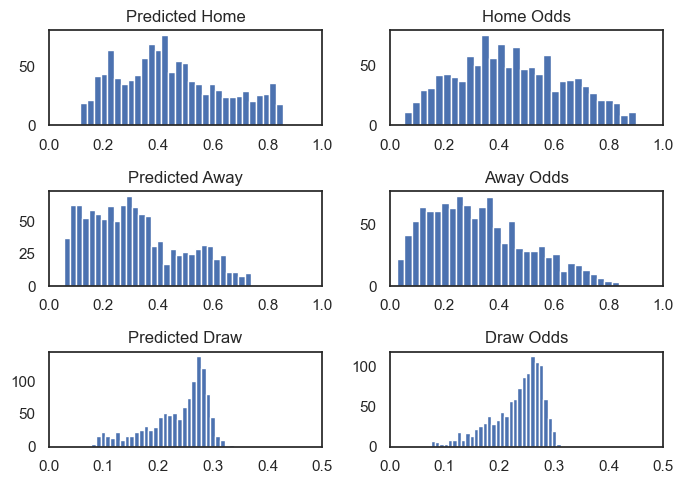

In [103]:
import matplotlib.pyplot as plt

# Data
pred_home = proba_rf_opt_df['pred_rf_opt_H'].dropna()
odds_home = proba_rf_opt_df['HomeOdds'].dropna()

pred_away = proba_rf_opt_df['pred_rf_opt_A'].dropna()
odds_away = proba_rf_opt_df['AwayOdds'].dropna()

pred_draw = proba_rf_opt_df['pred_rf_opt_D'].dropna()
odds_draw = proba_rf_opt_df['DrawOdds'].dropna()

plt.figure(figsize=(7, 5))

# --- HOME ---
plt.subplot(3, 2, 1)
plt.hist(pred_home, bins=30)
plt.xlim(0, 1)
plt.title('Predicted Home')

plt.subplot(3, 2, 2)
plt.hist(odds_home, bins=30)
plt.xlim(0, 1)
plt.title('Home Odds')

# --- AWAY ---
plt.subplot(3, 2, 3)
plt.hist(pred_away, bins=30)
plt.xlim(0, 1)
plt.title('Predicted Away')

plt.subplot(3, 2, 4)
plt.hist(odds_away, bins=30)
plt.xlim(0, 1)
plt.title('Away Odds')

# --- DRAW ---
plt.subplot(3, 2, 5)
plt.hist(pred_draw, bins=30)
plt.xlim(0, 0.5)
plt.title('Predicted Draw')

plt.subplot(3, 2, 6)
plt.hist(odds_draw, bins=30)
plt.xlim(0, 0.5)
plt.title('Draw Odds')

plt.tight_layout()
plt.show()

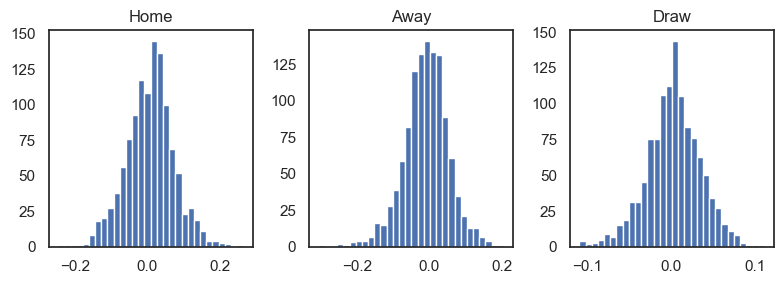

In [106]:
import matplotlib.pyplot as plt

homediff_rf = proba_rf_opt_df['homeOddsdiff'].dropna()
awaydiff_rf = proba_rf_opt_df['awayOddsdiff'].dropna()
drawdiff_rf = proba_rf_opt_df['drawOddsdiff'].dropna()

fig, axes = plt.subplots(1, 3, figsize=(8, 3))  # 👈 width, height in inches

axes[0].hist(homediff_rf, bins=30)
axes[0].set_title('Home')

axes[1].hist(awaydiff_rf, bins=30)
axes[1].set_title('Away')

axes[2].hist(drawdiff_rf, bins=30)
axes[2].set_title('Draw')

plt.tight_layout()
plt.show()

In [67]:
print("\nTEST Accuracy:", accuracy_score(y_test, pred_rf_opt))
print("TEST LogLoss:", log_loss(y_test, proba_rf_opt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred_rf_opt))


TEST Accuracy: 0.5408426483233018
TEST LogLoss: 0.9668122542961294

Confusion Matrix:
 [[423   0  99]
 [174   0  95]
 [166   0 206]]


In [66]:
print("\nClassification Report:\n", classification_report(y_test, pred_rf_opt, digits=3))


Classification Report:
               precision    recall  f1-score   support

           0      0.554     0.810     0.658       522
           1      0.000     0.000     0.000       269
           2      0.515     0.554     0.534       372

    accuracy                          0.541      1163
   macro avg      0.356     0.455     0.397      1163
weighted avg      0.414     0.541     0.466      1163



c:\Users\mikko\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mikko\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mikko\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [43]:
proba_rf_opt_rng = rf_opt.predict_proba(X_test)

rng = np.random.default_rng(42)

pred_rf_opt_rng = np.array([
    rng.choice(len(p), p=p) for p in proba_rf_opt_rng
])

In [69]:
print("TEST Accuracy:", accuracy_score(y_test, pred_rf_opt_rng))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred_rf_opt_rng))

TEST Accuracy: 0.42562338779019776

Confusion Matrix:
 [[283 124 115]
 [103  65 101]
 [138  87 147]]


In [68]:
print("\nClassification Report:\n", classification_report(y_test, pred_rf_opt_rng, digits=3))


Classification Report:
               precision    recall  f1-score   support

           0      0.540     0.542     0.541       522
           1      0.236     0.242     0.239       269
           2      0.405     0.395     0.400       372

    accuracy                          0.426      1163
   macro avg      0.394     0.393     0.393      1163
weighted avg      0.426     0.426     0.426      1163



In [45]:
X_rf_opt_last = X_test.iloc[[-1]]   # double brackets keep it 2D

pred_rf_opt_last = rf_opt.predict(X_rf_opt_last)
proba_rf_opt_last = rf_opt.predict_proba(X_rf_opt_last)

print("Predicted class:", pred_rf_opt_last)
print("Probabilities:", proba_rf_opt_last)

Predicted class: [2]
Probabilities: [[0.30916667 0.28285772 0.40797561]]


In [ ]:
model_xgb = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=5000,
    learning_rate=0.1,      
    max_depth=4,            
    min_child_weight=5,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    tree_method="hist",
    eval_metric="mlogloss",
    early_stopping_rounds=200,  
    random_state=42,
)

model_xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)

#metrics
proba_xgb = model_xgb.predict_proba(X_test)
pred_xgb = proba_xgb.argmax(axis=1)

print("Accuracy:", accuracy_score(y_test, pred_xgb))
print("LogLoss:", log_loss(y_test, proba_xgb))

print(confusion_matrix(y_test, pred_xgb))

[0]	validation_0-mlogloss:1.05005
[100]	validation_0-mlogloss:0.99064
[200]	validation_0-mlogloss:1.01003
[228]	validation_0-mlogloss:1.01486
Accuracy: 0.5399828030954428
LogLoss: 0.9733115027371481
[[423   2  97]
 [167   1 101]
 [162   6 204]]
              precision    recall  f1-score   support

           0      0.562     0.810     0.664       522
           1      0.111     0.004     0.007       269
           2      0.507     0.548     0.527       372

    accuracy                          0.540      1163
   macro avg      0.394     0.454     0.399      1163
weighted avg      0.440     0.540     0.468      1163



In [70]:
print(classification_report(y_test, pred_xgb, digits=3))

              precision    recall  f1-score   support

           0      0.562     0.810     0.664       522
           1      0.111     0.004     0.007       269
           2      0.507     0.548     0.527       372

    accuracy                          0.540      1163
   macro avg      0.394     0.454     0.399      1163
weighted avg      0.440     0.540     0.468      1163



In [73]:
proba_xgb_rng = model_xgb.predict_proba(X_test)

rng_xgb = np.random.default_rng(42)

pred_xgb_rng = np.array([
    rng.choice(len(p), p=p) for p in proba_xgb_rng
])

print(classification_report(y_test, pred_xgb_rng, digits=3))

              precision    recall  f1-score   support

           0      0.528     0.538     0.533       522
           1      0.244     0.230     0.237       269
           2      0.414     0.419     0.417       372

    accuracy                          0.429      1163
   macro avg      0.395     0.396     0.396      1163
weighted avg      0.426     0.429     0.427      1163



In [47]:
X_xgb_last = X_test.iloc[[-1]]   # double brackets keep it 2D

pred_xgb_last = model_xgb.predict(X_xgb_last)
proba_xgb_last = model_xgb.predict_proba(X_xgb_last)

print("Predicted class:", pred_xgb_last)
print("Probabilities:", proba_xgb_last)

Predicted class: [2]
Probabilities: [[0.28437126 0.28800598 0.4276227 ]]


In [48]:
proba_xgb_df = pd.DataFrame(proba_xgb, columns=['pred_xgb_H', 'pred_xgb_D', 'pred_xgb_A'])
proba_xgb_df = pd.concat([proba_xgb_df.reset_index(drop=True), Features_odds], axis=1)
proba_xgb_df

,pred_xgb_H,pred_xgb_D,pred_xgb_A,HomeOdds,DrawOdds,AwayOdds
0,0.559035,0.245385,0.195580,0.368517,0.287973,0.343510
1,0.280146,0.252552,0.467302,0.213252,0.252432,0.534315
2,0.812996,0.069710,0.117294,0.817383,0.126410,0.056207
3,0.220632,0.161944,0.617424,0.131240,0.198889,0.669871
4,0.195429,0.145641,0.658930,0.193189,0.230715,0.576096
...,...,...,...,...,...,...
1158,0.330110,0.207881,0.462009,0.309101,0.256753,0.434146
1159,0.163592,0.186547,0.649861,0.100538,0.162964,0.736498
1160,0.667700,0.184526,0.147774,0.721382,0.170040,0.108578
1161,0.659529,0.175369,0.165103,0.679776,0.168440,0.151784


In [49]:


SEED = 42
N_CLASSES = 3

# convert y if DataFrame with one column
if hasattr(y_train, "shape") and len(y_train.shape) == 2:
    y_train = y_train.iloc[:,0]
    y_test = y_test.iloc[:,0]

def objective(trial):

    params_xgbo = {
        "objective": "multi:softprob",
        "num_class": N_CLASSES,
        "tree_method": "hist",
        "eval_metric": "mlogloss",
        "random_state": SEED,
        "n_jobs": -1,

        # hyperparameters to tune
        "n_estimators": trial.suggest_int("n_estimators", 1000, 12000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 10),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 20.0),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 50.0, log=True),

        "gamma": trial.suggest_float("gamma", 0.0, 10.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 5.0, log=True),

        # early stopping goes HERE for xgboost >=3
        "early_stopping_rounds": 200,
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    losses = []

    for tr_idx, va_idx in cv.split(X_train, y_train):

        X_tr = X_train.iloc[tr_idx]
        X_va = X_train.iloc[va_idx]
        y_tr = y_train.iloc[tr_idx]
        y_va = y_train.iloc[va_idx]

        model_xgb_o = xgb.XGBClassifier(**params_xgbo)

        model_xgb_o.fit(
            X_tr,
            y_tr,
            eval_set=[(X_va, y_va)],
            verbose=False
        )

        proba_xgbo = model_xgb_o.predict_proba(X_va)
        losses.append(log_loss(y_va, proba_xgbo, labels=np.arange(N_CLASSES)))

    return -np.mean(losses)


study_xgb = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED)
)

study_xgb.optimize(objective, n_trials=60, show_progress_bar=True)

print("\nBest CV neg_log_loss:", study_xgb.best_value)
print("Best params:\n", study_xgb.best_params)


# ---- train final optimized model ----

best_params_xgb = {
    **study_xgb.best_params,
    "objective": "multi:softprob",
    "num_class": N_CLASSES,
    "tree_method": "hist",
    "eval_metric": "mlogloss",
    "random_state": SEED,
    "n_jobs": -1,
    "early_stopping_rounds": 200,
}

model_xgb_opt = xgb.XGBClassifier(**best_params_xgb)

model_xgb_opt.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)


[I 2026-03-19 13:15:32,536] A new study created in memory with name: no-name-e87d9942-e3d0-4e2c-bd2f-6a9c5a2e1bdf
Best trial: 0. Best value: -0.979054:   2%|▏         | 1/60 [00:04<04:50,  4.93s/it]

[I 2026-03-19 13:15:37,462] Trial 0 finished with value: -0.9790536262172015 and parameters: {'n_estimators': 5120, 'learning_rate': 0.2536999076681772, 'max_depth': 8, 'min_child_weight': 12.374511199743695, 'subsample': 0.5780093202212182, 'colsample_bytree': 0.5779972601681014, 'reg_lambda': 0.0018747059221802516, 'gamma': 8.661761457749352, 'reg_alpha': 0.0016946556203947059}. Best is trial 0 with value: -0.9790536262172015.


Best trial: 1. Best value: -0.977235:   3%|▎         | 2/60 [00:15<08:06,  8.39s/it]

[I 2026-03-19 13:15:48,274] Trial 1 finished with value: -0.9772347198473186 and parameters: {'n_estimators': 8789, 'learning_rate': 0.010725209743171996, 'max_depth': 10, 'min_child_weight': 16.816410175208013, 'subsample': 0.6061695553391381, 'colsample_bytree': 0.5909124836035503, 'reg_lambda': 0.0072746531356694235, 'gamma': 3.0424224295953772, 'reg_alpha': 0.0003671474011048667}. Best is trial 1 with value: -0.9772347198473186.


Best trial: 1. Best value: -0.977235:   5%|▌         | 3/60 [00:28<09:45, 10.27s/it]

[I 2026-03-19 13:16:00,793] Trial 2 finished with value: -0.977863935650538 and parameters: {'n_estimators': 5751, 'learning_rate': 0.02692655251486473, 'max_depth': 7, 'min_child_weight': 3.6503833523887947, 'subsample': 0.6460723242676091, 'colsample_bytree': 0.6831809216468459, 'reg_lambda': 0.1390142035054592, 'gamma': 7.851759613930136, 'reg_alpha': 5.457028747569545e-07}. Best is trial 1 with value: -0.9772347198473186.


Best trial: 1. Best value: -0.977235:   7%|▋         | 4/60 [00:42<11:04, 11.87s/it]

[I 2026-03-19 13:16:15,103] Trial 3 finished with value: -0.9801563377718148 and parameters: {'n_estimators': 6657, 'learning_rate': 0.07500118950416987, 'max_depth': 2, 'min_child_weight': 12.54335218612733, 'subsample': 0.5852620618436457, 'colsample_bytree': 0.5325257964926398, 'reg_lambda': 28.759721562259614, 'gamma': 9.656320330745594, 'reg_alpha': 0.10770212765048791}. Best is trial 1 with value: -0.9772347198473186.


Best trial: 1. Best value: -0.977235:   8%|▊         | 5/60 [01:10<16:19, 17.81s/it]

[I 2026-03-19 13:16:43,447] Trial 4 finished with value: -0.9782317831615075 and parameters: {'n_estimators': 4351, 'learning_rate': 0.013940346079873234, 'max_depth': 8, 'min_child_weight': 9.362897381052425, 'subsample': 0.5610191174223894, 'colsample_bytree': 0.7475884550556351, 'reg_lambda': 0.0014507434860119778, 'gamma': 9.093204020787821, 'reg_alpha': 1.7828684416997836e-06}. Best is trial 1 with value: -0.9772347198473186.


Best trial: 1. Best value: -0.977235:  10%|█         | 6/60 [01:32<17:07, 19.03s/it]

[I 2026-03-19 13:17:04,846] Trial 5 finished with value: -0.9780956598366192 and parameters: {'n_estimators': 8288, 'learning_rate': 0.028869220380495747, 'max_depth': 6, 'min_child_weight': 11.387495307522313, 'subsample': 0.5924272277627636, 'colsample_bytree': 0.9847923138822793, 'reg_lambda': 4.388598863942796, 'gamma': 9.394989415641891, 'reg_alpha': 0.6082418248172017}. Best is trial 1 with value: -0.9772347198473186.


Best trial: 6. Best value: -0.976848:  12%|█▏        | 7/60 [01:35<12:14, 13.86s/it]

[I 2026-03-19 13:17:08,060] Trial 6 finished with value: -0.9768481778222189 and parameters: {'n_estimators': 7577, 'learning_rate': 0.22999586428143728, 'max_depth': 2, 'min_child_weight': 4.723674385963759, 'subsample': 0.522613644455269, 'colsample_bytree': 0.6626651653816322, 'reg_lambda': 0.06704755197530224, 'gamma': 2.713490317738959, 'reg_alpha': 0.16186864586521713}. Best is trial 6 with value: -0.9768481778222189.


Best trial: 6. Best value: -0.976848:  13%|█▎        | 8/60 [01:46<11:08, 12.86s/it]

[I 2026-03-19 13:17:18,769] Trial 7 finished with value: -0.9798939121589999 and parameters: {'n_estimators': 4924, 'learning_rate': 0.026000059117302653, 'max_depth': 6, 'min_child_weight': 3.6775602745204905, 'subsample': 0.9010984903770198, 'colsample_bytree': 0.5372753218398854, 'reg_lambda': 43.38624983446471, 'gamma': 7.722447692966574, 'reg_alpha': 5.35330210833913e-07}. Best is trial 6 with value: -0.9768481778222189.


Best trial: 6. Best value: -0.976848:  15%|█▌        | 9/60 [01:49<08:24,  9.89s/it]

[I 2026-03-19 13:17:22,128] Trial 8 finished with value: -0.9870868374377221 and parameters: {'n_estimators': 1060, 'learning_rate': 0.1601531217136121, 'max_depth': 8, 'min_child_weight': 14.851136192778759, 'subsample': 0.8856351733429728, 'colsample_bytree': 0.5370223258670452, 'reg_lambda': 0.04835258599682954, 'gamma': 1.1586905952512971, 'reg_alpha': 0.32218907673802705}. Best is trial 6 with value: -0.9768481778222189.


Best trial: 6. Best value: -0.976848:  17%|█▋        | 10/60 [02:06<10:01, 12.03s/it]

[I 2026-03-19 13:17:38,970] Trial 9 finished with value: -0.9778900125377342 and parameters: {'n_estimators': 7856, 'learning_rate': 0.030816017044468066, 'max_depth': 2, 'min_child_weight': 6.908664112597582, 'subsample': 0.6625916610133735, 'colsample_bytree': 0.864803089169032, 'reg_lambda': 0.9905204218383901, 'gamma': 8.872127425763265, 'reg_alpha': 0.00012816913980027156}. Best is trial 6 with value: -0.9768481778222189.


Best trial: 6. Best value: -0.976848:  18%|█▊        | 11/60 [02:09<07:36,  9.32s/it]

[I 2026-03-19 13:17:42,121] Trial 10 finished with value: -0.9787090727718171 and parameters: {'n_estimators': 11489, 'learning_rate': 0.10417088978859979, 'max_depth': 4, 'min_child_weight': 1.34127563668158, 'subsample': 0.7828065453407016, 'colsample_bytree': 0.6808837830192477, 'reg_lambda': 0.018106433958753353, 'gamma': 3.924528921026324, 'reg_alpha': 0.006591030967925392}. Best is trial 6 with value: -0.9768481778222189.


Best trial: 6. Best value: -0.976848:  20%|██        | 12/60 [02:12<05:57,  7.44s/it]

[I 2026-03-19 13:17:45,272] Trial 11 finished with value: -0.9815920444642332 and parameters: {'n_estimators': 10125, 'learning_rate': 0.2923054009644287, 'max_depth': 10, 'min_child_weight': 18.51589588264785, 'subsample': 0.5156896024754595, 'colsample_bytree': 0.6362066546548342, 'reg_lambda': 0.013429680269363501, 'gamma': 3.111526195286856, 'reg_alpha': 9.909057816762803e-05}. Best is trial 6 with value: -0.9768481778222189.


Best trial: 6. Best value: -0.976848:  22%|██▏       | 13/60 [02:26<07:15,  9.26s/it]

[I 2026-03-19 13:17:58,730] Trial 12 finished with value: -0.981481851805618 and parameters: {'n_estimators': 8880, 'learning_rate': 0.0122839419962954, 'max_depth': 10, 'min_child_weight': 19.974521139096183, 'subsample': 0.7343526094439211, 'colsample_bytree': 0.7921336951296047, 'reg_lambda': 0.007136981691829091, 'gamma': 1.040286131020716, 'reg_alpha': 2.8076480598129594}. Best is trial 6 with value: -0.9768481778222189.


Best trial: 13. Best value: -0.97663:  23%|██▎       | 14/60 [02:31<06:07,  7.99s/it]

[I 2026-03-19 13:18:03,780] Trial 13 finished with value: -0.9766299072213351 and parameters: {'n_estimators': 10157, 'learning_rate': 0.051098201253078505, 'max_depth': 4, 'min_child_weight': 16.19852845573252, 'subsample': 0.5013757785563149, 'colsample_bytree': 0.6223441463224711, 'reg_lambda': 0.38697523652192395, 'gamma': 5.2498997564890715, 'reg_alpha': 0.009187218047421591}. Best is trial 13 with value: -0.9766299072213351.


Best trial: 14. Best value: -0.976525:  25%|██▌       | 15/60 [02:37<05:37,  7.50s/it]

[I 2026-03-19 13:18:10,133] Trial 14 finished with value: -0.9765253640473389 and parameters: {'n_estimators': 11747, 'learning_rate': 0.05605945113063423, 'max_depth': 4, 'min_child_weight': 7.854098403005041, 'subsample': 0.5140230656274163, 'colsample_bytree': 0.756165400025059, 'reg_lambda': 0.48082269141529865, 'gamma': 6.29540378885119, 'reg_alpha': 0.01988842798453708}. Best is trial 14 with value: -0.9765253640473389.


Best trial: 14. Best value: -0.976525:  27%|██▋       | 16/60 [02:43<05:13,  7.13s/it]

[I 2026-03-19 13:18:16,414] Trial 15 finished with value: -0.9770176851673178 and parameters: {'n_estimators': 11836, 'learning_rate': 0.0583762271222965, 'max_depth': 4, 'min_child_weight': 8.377142816778003, 'subsample': 0.724274028445038, 'colsample_bytree': 0.7714270006855597, 'reg_lambda': 0.7643561424808978, 'gamma': 6.092599562105124, 'reg_alpha': 0.023635307429998004}. Best is trial 14 with value: -0.9765253640473389.


Best trial: 16. Best value: -0.975844:  28%|██▊       | 17/60 [02:52<05:24,  7.55s/it]

[I 2026-03-19 13:18:24,937] Trial 16 finished with value: -0.9758437136743876 and parameters: {'n_estimators': 10598, 'learning_rate': 0.04353837849838075, 'max_depth': 4, 'min_child_weight': 14.72230031943193, 'subsample': 0.5019126804032951, 'colsample_bytree': 0.8754986180062628, 'reg_lambda': 0.4147273141848499, 'gamma': 5.873196021519129, 'reg_alpha': 1.3021037527817063e-08}. Best is trial 16 with value: -0.9758437136743876.


Best trial: 16. Best value: -0.975844:  30%|███       | 18/60 [03:02<05:47,  8.27s/it]

[I 2026-03-19 13:18:34,894] Trial 17 finished with value: -0.9770412664519741 and parameters: {'n_estimators': 10473, 'learning_rate': 0.044088914536090165, 'max_depth': 5, 'min_child_weight': 14.057771509666791, 'subsample': 0.8132394567758081, 'colsample_bytree': 0.8979387218009911, 'reg_lambda': 2.4982084527792066, 'gamma': 6.4294794427455235, 'reg_alpha': 1.8933920715019438e-08}. Best is trial 16 with value: -0.9758437136743876.


Best trial: 16. Best value: -0.975844:  32%|███▏      | 19/60 [03:11<05:48,  8.49s/it]

[I 2026-03-19 13:18:43,889] Trial 18 finished with value: -0.9775966875885154 and parameters: {'n_estimators': 3250, 'learning_rate': 0.0969193339743378, 'max_depth': 3, 'min_child_weight': 7.777375424453348, 'subsample': 0.6663880394956969, 'colsample_bytree': 0.8614645549243602, 'reg_lambda': 7.035805464578631, 'gamma': 6.857171713765338, 'reg_alpha': 1.3522820124573307e-05}. Best is trial 16 with value: -0.9758437136743876.


Best trial: 16. Best value: -0.975844:  33%|███▎      | 20/60 [03:15<04:53,  7.33s/it]

[I 2026-03-19 13:18:48,512] Trial 19 finished with value: -0.975904348923114 and parameters: {'n_estimators': 10717, 'learning_rate': 0.14168046193643366, 'max_depth': 5, 'min_child_weight': 6.315045824757371, 'subsample': 0.85377031755662, 'colsample_bytree': 0.9466841924883267, 'reg_lambda': 0.2193059760478956, 'gamma': 4.76483376659523, 'reg_alpha': 2.383208707094935e-08}. Best is trial 16 with value: -0.9758437136743876.


Best trial: 16. Best value: -0.975844:  35%|███▌      | 21/60 [03:21<04:28,  6.89s/it]

[I 2026-03-19 13:18:54,396] Trial 20 finished with value: -0.9776229016987606 and parameters: {'n_estimators': 9425, 'learning_rate': 0.16019478265357012, 'max_depth': 5, 'min_child_weight': 6.1086062910855015, 'subsample': 0.9983517114850313, 'colsample_bytree': 0.9859598689068377, 'reg_lambda': 0.1773140968036522, 'gamma': 4.441346418554474, 'reg_alpha': 1.4221140452520742e-08}. Best is trial 16 with value: -0.9758437136743876.


Best trial: 16. Best value: -0.975844:  37%|███▋      | 22/60 [03:38<06:10,  9.75s/it]

[I 2026-03-19 13:19:10,812] Trial 21 finished with value: -0.976656881697442 and parameters: {'n_estimators': 11860, 'learning_rate': 0.017429082404149393, 'max_depth': 5, 'min_child_weight': 10.300270266700965, 'subsample': 0.8611026042284101, 'colsample_bytree': 0.9253085663206508, 'reg_lambda': 0.5343187970205789, 'gamma': 5.328745056826581, 'reg_alpha': 6.349527123714623e-08}. Best is trial 16 with value: -0.9758437136743876.


Best trial: 16. Best value: -0.975844:  38%|███▊      | 23/60 [03:46<05:39,  9.18s/it]

[I 2026-03-19 13:19:18,658] Trial 22 finished with value: -0.9776833149013961 and parameters: {'n_estimators': 10488, 'learning_rate': 0.03844084690875403, 'max_depth': 3, 'min_child_weight': 9.504005452703025, 'subsample': 0.9505474160288899, 'colsample_bytree': 0.8115766335062022, 'reg_lambda': 1.8871699151220676, 'gamma': 5.6488640643691035, 'reg_alpha': 1.1957768096929653e-07}. Best is trial 16 with value: -0.9758437136743876.


Best trial: 16. Best value: -0.975844:  40%|████      | 24/60 [03:53<05:09,  8.59s/it]

[I 2026-03-19 13:19:25,861] Trial 23 finished with value: -0.9772706068561794 and parameters: {'n_estimators': 11012, 'learning_rate': 0.07242958895508365, 'max_depth': 3, 'min_child_weight': 5.631104410397244, 'subsample': 0.7958561724249666, 'colsample_bytree': 0.9480062150711577, 'reg_lambda': 0.07315998263010419, 'gamma': 7.135631631916836, 'reg_alpha': 1.922545616149179e-06}. Best is trial 16 with value: -0.9758437136743876.


Best trial: 16. Best value: -0.975844:  42%|████▏     | 25/60 [03:57<04:10,  7.15s/it]

[I 2026-03-19 13:19:29,656] Trial 24 finished with value: -0.976873909452407 and parameters: {'n_estimators': 9774, 'learning_rate': 0.10413957871288852, 'max_depth': 5, 'min_child_weight': 8.059579246110843, 'subsample': 0.8357365970294518, 'colsample_bytree': 0.8323065597324298, 'reg_lambda': 0.3418779959411134, 'gamma': 4.457769366151809, 'reg_alpha': 1.2324454445969434e-05}. Best is trial 16 with value: -0.9758437136743876.


Best trial: 16. Best value: -0.975844:  43%|████▎     | 26/60 [04:00<03:21,  5.93s/it]

[I 2026-03-19 13:19:32,746] Trial 25 finished with value: -0.9801981586112968 and parameters: {'n_estimators': 11025, 'learning_rate': 0.16279523097294188, 'max_depth': 4, 'min_child_weight': 2.7942603547073697, 'subsample': 0.7097201599161166, 'colsample_bytree': 0.7286889810510169, 'reg_lambda': 8.804922573785227, 'gamma': 2.118567271129225, 'reg_alpha': 1.0128208417144915e-07}. Best is trial 16 with value: -0.9758437136743876.


Best trial: 16. Best value: -0.975844:  45%|████▌     | 27/60 [04:07<03:27,  6.29s/it]

[I 2026-03-19 13:19:39,859] Trial 26 finished with value: -0.9765735129485336 and parameters: {'n_estimators': 7201, 'learning_rate': 0.019388808299566053, 'max_depth': 7, 'min_child_weight': 13.210123825397908, 'subsample': 0.5423685915255476, 'colsample_bytree': 0.9089289950084383, 'reg_lambda': 1.5336463249011496, 'gamma': 3.8757626299426224, 'reg_alpha': 1.936914641229064e-05}. Best is trial 16 with value: -0.9758437136743876.


Best trial: 16. Best value: -0.975844:  47%|████▋     | 28/60 [04:14<03:26,  6.45s/it]

[I 2026-03-19 13:19:46,685] Trial 27 finished with value: -0.9774623720472686 and parameters: {'n_estimators': 9500, 'learning_rate': 0.07095058876520938, 'max_depth': 3, 'min_child_weight': 10.605944261134551, 'subsample': 0.9043866013878834, 'colsample_bytree': 0.8684002572919136, 'reg_lambda': 0.18487723769698183, 'gamma': 6.094094827966521, 'reg_alpha': 0.0007646921542251738}. Best is trial 16 with value: -0.9758437136743876.


Best trial: 16. Best value: -0.975844:  48%|████▊     | 29/60 [04:20<03:17,  6.36s/it]

[I 2026-03-19 13:19:52,831] Trial 28 finished with value: -0.9765175988766288 and parameters: {'n_estimators': 8835, 'learning_rate': 0.03854988202846305, 'max_depth': 6, 'min_child_weight': 15.0966336224135, 'subsample': 0.6145773566887293, 'colsample_bytree': 0.9321830240742816, 'reg_lambda': 0.034146653458928956, 'gamma': 4.727871310209272, 'reg_alpha': 1.4168136047445695e-08}. Best is trial 16 with value: -0.9758437136743876.


Best trial: 16. Best value: -0.975844:  50%|█████     | 30/60 [04:28<03:29,  6.98s/it]

[I 2026-03-19 13:20:01,272] Trial 29 finished with value: -0.9796324032872938 and parameters: {'n_estimators': 8406, 'learning_rate': 0.022183341045142614, 'max_depth': 6, 'min_child_weight': 15.716327753248772, 'subsample': 0.6272353029327429, 'colsample_bytree': 0.9614446966831018, 'reg_lambda': 0.02656339742206962, 'gamma': 0.1034843896909674, 'reg_alpha': 1.084114256435441e-08}. Best is trial 16 with value: -0.9758437136743876.


Best trial: 16. Best value: -0.975844:  52%|█████▏    | 31/60 [04:35<03:19,  6.87s/it]

[I 2026-03-19 13:20:07,873] Trial 30 finished with value: -0.9762949898653629 and parameters: {'n_estimators': 9182, 'learning_rate': 0.036406726897615094, 'max_depth': 7, 'min_child_weight': 17.656830940985735, 'subsample': 0.7558933844506434, 'colsample_bytree': 0.9447681806631013, 'reg_lambda': 0.0037886728357206666, 'gamma': 4.638118288484325, 'reg_alpha': 4.4907521247325334e-07}. Best is trial 16 with value: -0.9758437136743876.


Best trial: 16. Best value: -0.975844:  53%|█████▎    | 32/60 [04:40<02:59,  6.42s/it]

[I 2026-03-19 13:20:13,235] Trial 31 finished with value: -0.9766732152470372 and parameters: {'n_estimators': 9129, 'learning_rate': 0.03655165762147974, 'max_depth': 7, 'min_child_weight': 17.56029402407705, 'subsample': 0.6948673013653471, 'colsample_bytree': 0.9389448613031051, 'reg_lambda': 0.002773797321786677, 'gamma': 4.633334458767154, 'reg_alpha': 4.998808681473285e-08}. Best is trial 16 with value: -0.9758437136743876.


Best trial: 16. Best value: -0.975844:  55%|█████▌    | 33/60 [04:47<02:59,  6.65s/it]

[I 2026-03-19 13:20:20,426] Trial 32 finished with value: -0.9772613369724592 and parameters: {'n_estimators': 10567, 'learning_rate': 0.03722856605940659, 'max_depth': 6, 'min_child_weight': 18.823059363860875, 'subsample': 0.761802872022243, 'colsample_bytree': 0.9990635616502506, 'reg_lambda': 0.0028830309863195204, 'gamma': 3.680364850039541, 'reg_alpha': 2.885818997604797e-07}. Best is trial 16 with value: -0.9758437136743876.


Best trial: 16. Best value: -0.975844:  57%|█████▋    | 34/60 [04:53<02:48,  6.48s/it]

[I 2026-03-19 13:20:26,527] Trial 33 finished with value: -0.9766296802211493 and parameters: {'n_estimators': 6334, 'learning_rate': 0.046750901585139365, 'max_depth': 8, 'min_child_weight': 14.901281180682023, 'subsample': 0.6185528623711536, 'colsample_bytree': 0.8858818006273804, 'reg_lambda': 0.00614024069595065, 'gamma': 4.899538869150387, 'reg_alpha': 1.7310959483107804e-06}. Best is trial 16 with value: -0.9758437136743876.


Best trial: 16. Best value: -0.975844:  58%|█████▊    | 35/60 [05:08<03:45,  9.03s/it]

[I 2026-03-19 13:20:41,493] Trial 34 finished with value: -0.9772368564306255 and parameters: {'n_estimators': 8564, 'learning_rate': 0.032213600628621504, 'max_depth': 7, 'min_child_weight': 17.125959091969438, 'subsample': 0.6851365492545872, 'colsample_bytree': 0.9588209557747818, 'reg_lambda': 0.03492512561475359, 'gamma': 7.682470802422098, 'reg_alpha': 3.9777869599049866e-08}. Best is trial 16 with value: -0.9758437136743876.


Best trial: 16. Best value: -0.975844:  60%|██████    | 36/60 [05:13<03:05,  7.72s/it]

[I 2026-03-19 13:20:46,165] Trial 35 finished with value: -0.9758966610341668 and parameters: {'n_estimators': 11117, 'learning_rate': 0.08268247450843774, 'max_depth': 7, 'min_child_weight': 12.441096857508452, 'subsample': 0.5505271679165693, 'colsample_bytree': 0.9204133352833715, 'reg_lambda': 0.09414938062320269, 'gamma': 5.726357725327292, 'reg_alpha': 2.652486124937815e-07}. Best is trial 16 with value: -0.9758437136743876.


Best trial: 16. Best value: -0.975844:  62%|██████▏   | 37/60 [05:21<02:55,  7.65s/it]

[I 2026-03-19 13:20:53,638] Trial 36 finished with value: -0.9776821412417931 and parameters: {'n_estimators': 10952, 'learning_rate': 0.13415137539382296, 'max_depth': 9, 'min_child_weight': 12.97723330445598, 'subsample': 0.5801000212575286, 'colsample_bytree': 0.8467260070306885, 'reg_lambda': 0.0915097703782094, 'gamma': 8.287931271359861, 'reg_alpha': 2.627702048336912e-07}. Best is trial 16 with value: -0.9758437136743876.


Best trial: 37. Best value: -0.975603:  63%|██████▎   | 38/60 [05:25<02:23,  6.53s/it]

[I 2026-03-19 13:20:57,572] Trial 37 finished with value: -0.9756033911457461 and parameters: {'n_estimators': 11250, 'learning_rate': 0.08308734660168812, 'max_depth': 9, 'min_child_weight': 11.105588292250754, 'subsample': 0.5504226663385433, 'colsample_bytree': 0.8964357642680781, 'reg_lambda': 0.001045011816031867, 'gamma': 5.642929760631735, 'reg_alpha': 2.9034162316123236e-06}. Best is trial 37 with value: -0.9756033911457461.


Best trial: 37. Best value: -0.975603:  65%|██████▌   | 39/60 [05:29<02:07,  6.05s/it]

[I 2026-03-19 13:21:02,499] Trial 38 finished with value: -0.9758185960931124 and parameters: {'n_estimators': 11079, 'learning_rate': 0.08740447277076892, 'max_depth': 10, 'min_child_weight': 11.523126742035512, 'subsample': 0.554975234485456, 'colsample_bytree': 0.9055559156414702, 'reg_lambda': 0.11887235562447397, 'gamma': 5.585458741561408, 'reg_alpha': 2.4838067996578478e-06}. Best is trial 37 with value: -0.9756033911457461.


Best trial: 37. Best value: -0.975603:  67%|██████▋   | 40/60 [05:35<02:00,  6.02s/it]

[I 2026-03-19 13:21:08,446] Trial 39 finished with value: -0.9764670808632928 and parameters: {'n_estimators': 11311, 'learning_rate': 0.07965593478726157, 'max_depth': 9, 'min_child_weight': 11.568098792585818, 'subsample': 0.552358325677924, 'colsample_bytree': 0.8991670988362398, 'reg_lambda': 0.10901991697395425, 'gamma': 7.103334029123063, 'reg_alpha': 4.016532308766111e-06}. Best is trial 37 with value: -0.9756033911457461.


Best trial: 37. Best value: -0.975603:  68%|██████▊   | 41/60 [05:39<01:41,  5.35s/it]

[I 2026-03-19 13:21:12,222] Trial 40 finished with value: -0.9763107657579784 and parameters: {'n_estimators': 9873, 'learning_rate': 0.08798461242708135, 'max_depth': 9, 'min_child_weight': 11.986018059272775, 'subsample': 0.5667687984804605, 'colsample_bytree': 0.8289549878257999, 'reg_lambda': 0.0010158125215617535, 'gamma': 5.640689473484699, 'reg_alpha': 3.1160477324801876e-05}. Best is trial 37 with value: -0.9756033911457461.


Best trial: 41. Best value: -0.97533:  70%|███████   | 42/60 [05:43<01:27,  4.84s/it] 

[I 2026-03-19 13:21:15,879] Trial 41 finished with value: -0.9753296878322482 and parameters: {'n_estimators': 10925, 'learning_rate': 0.13862002312424412, 'max_depth': 10, 'min_child_weight': 13.63779366777248, 'subsample': 0.5404722439729613, 'colsample_bytree': 0.9708987289353609, 'reg_lambda': 0.17198411595435464, 'gamma': 5.655166465587147, 'reg_alpha': 1.3281201631713736e-06}. Best is trial 41 with value: -0.9753296878322482.


Best trial: 41. Best value: -0.97533:  72%|███████▏  | 43/60 [05:46<01:13,  4.32s/it]

[I 2026-03-19 13:21:18,987] Trial 42 finished with value: -0.9760828374444405 and parameters: {'n_estimators': 11280, 'learning_rate': 0.2090792194611632, 'max_depth': 10, 'min_child_weight': 13.092408309978598, 'subsample': 0.5364482868917997, 'colsample_bytree': 0.9129910634552907, 'reg_lambda': 0.29865096633330995, 'gamma': 5.68577113813747, 'reg_alpha': 5.384360269047628e-06}. Best is trial 41 with value: -0.9753296878322482.


Best trial: 41. Best value: -0.97533:  73%|███████▎  | 44/60 [05:51<01:11,  4.48s/it]

[I 2026-03-19 13:21:23,855] Trial 43 finished with value: -0.9768428950388748 and parameters: {'n_estimators': 3477, 'learning_rate': 0.11519265509839785, 'max_depth': 9, 'min_child_weight': 14.016183723543165, 'subsample': 0.6003181970507163, 'colsample_bytree': 0.9739541348634604, 'reg_lambda': 0.13499621583545868, 'gamma': 6.68105168363169, 'reg_alpha': 1.6540090190284673e-06}. Best is trial 41 with value: -0.9753296878322482.


Best trial: 41. Best value: -0.97533:  75%|███████▌  | 45/60 [06:00<01:27,  5.86s/it]

[I 2026-03-19 13:21:32,931] Trial 44 finished with value: -0.9767359693698282 and parameters: {'n_estimators': 11899, 'learning_rate': 0.06429222384477834, 'max_depth': 10, 'min_child_weight': 10.722630621394742, 'subsample': 0.5731901562834261, 'colsample_bytree': 0.880437113867963, 'reg_lambda': 0.0171576184753926, 'gamma': 7.389765996776988, 'reg_alpha': 7.859192691291475e-07}. Best is trial 41 with value: -0.9753296878322482.


Best trial: 41. Best value: -0.97533:  77%|███████▋  | 46/60 [06:04<01:13,  5.23s/it]

[I 2026-03-19 13:21:36,677] Trial 45 finished with value: -0.9756076343569984 and parameters: {'n_estimators': 10384, 'learning_rate': 0.12306511287945639, 'max_depth': 9, 'min_child_weight': 13.83155698546032, 'subsample': 0.5347849241678923, 'colsample_bytree': 0.9205077801558228, 'reg_lambda': 1.11530005280564, 'gamma': 5.842176719005939, 'reg_alpha': 5.8026010056551196e-05}. Best is trial 41 with value: -0.9753296878322482.


Best trial: 41. Best value: -0.97533:  78%|███████▊  | 47/60 [06:07<01:01,  4.76s/it]

[I 2026-03-19 13:21:40,337] Trial 46 finished with value: -0.9758867178463995 and parameters: {'n_estimators': 10106, 'learning_rate': 0.20237500999400865, 'max_depth': 8, 'min_child_weight': 13.98682748829051, 'subsample': 0.5313965650324218, 'colsample_bytree': 0.8031736678102505, 'reg_lambda': 14.13738593052429, 'gamma': 5.229961215582369, 'reg_alpha': 5.6918715491056586e-05}. Best is trial 41 with value: -0.9753296878322482.


Best trial: 41. Best value: -0.97533:  80%|████████  | 48/60 [06:16<01:10,  5.89s/it]

[I 2026-03-19 13:21:48,856] Trial 47 finished with value: -0.9765688983306896 and parameters: {'n_estimators': 7929, 'learning_rate': 0.13746742522706773, 'max_depth': 10, 'min_child_weight': 9.39863096030979, 'subsample': 0.5999658043847019, 'colsample_bytree': 0.9735493000133941, 'reg_lambda': 0.8538366783499387, 'gamma': 8.359030379476579, 'reg_alpha': 0.0004297455855541139}. Best is trial 41 with value: -0.9753296878322482.


Best trial: 41. Best value: -0.97533:  82%|████████▏ | 49/60 [06:21<01:01,  5.60s/it]

[I 2026-03-19 13:21:53,781] Trial 48 finished with value: -0.975695504360542 and parameters: {'n_estimators': 9738, 'learning_rate': 0.12306515155513022, 'max_depth': 9, 'min_child_weight': 15.898900782862809, 'subsample': 0.5028485034490305, 'colsample_bytree': 0.8479755617622919, 'reg_lambda': 3.7553411316473775, 'gamma': 6.425106196421261, 'reg_alpha': 0.00015926408085842157}. Best is trial 41 with value: -0.9753296878322482.


Best trial: 41. Best value: -0.97533:  83%|████████▎ | 50/60 [06:27<00:58,  5.81s/it]

[I 2026-03-19 13:22:00,094] Trial 49 finished with value: -0.977062889377794 and parameters: {'n_estimators': 11469, 'learning_rate': 0.11847855523266479, 'max_depth': 9, 'min_child_weight': 15.87382589557389, 'subsample': 0.6470342262143909, 'colsample_bytree': 0.8393038106447913, 'reg_lambda': 2.9719841026293294, 'gamma': 6.503597579578545, 'reg_alpha': 0.001960247452690802}. Best is trial 41 with value: -0.9753296878322482.


Best trial: 41. Best value: -0.97533:  85%|████████▌ | 51/60 [06:30<00:45,  5.02s/it]

[I 2026-03-19 13:22:03,255] Trial 50 finished with value: -0.9755953322831322 and parameters: {'n_estimators': 1633, 'learning_rate': 0.18148926317618314, 'max_depth': 9, 'min_child_weight': 11.244486660266098, 'subsample': 0.5196890194017545, 'colsample_bytree': 0.8587617287953592, 'reg_lambda': 4.35905669598551, 'gamma': 3.450342078635799, 'reg_alpha': 0.00017304687267593284}. Best is trial 41 with value: -0.9753296878322482.


Best trial: 41. Best value: -0.97533:  87%|████████▋ | 52/60 [06:33<00:35,  4.43s/it]

[I 2026-03-19 13:22:06,307] Trial 51 finished with value: -0.975815363742998 and parameters: {'n_estimators': 1828, 'learning_rate': 0.17182860512238088, 'max_depth': 9, 'min_child_weight': 11.34337269911296, 'subsample': 0.5260833068221666, 'colsample_bytree': 0.7205814762119102, 'reg_lambda': 5.4050988908130755, 'gamma': 3.3434484220158915, 'reg_alpha': 0.00013244345113662046}. Best is trial 41 with value: -0.9753296878322482.


Best trial: 41. Best value: -0.97533:  88%|████████▊ | 53/60 [06:37<00:28,  4.12s/it]

[I 2026-03-19 13:22:09,696] Trial 52 finished with value: -0.9783157592218551 and parameters: {'n_estimators': 1207, 'learning_rate': 0.1869245327668666, 'max_depth': 9, 'min_child_weight': 10.044461701142119, 'subsample': 0.5178420709264635, 'colsample_bytree': 0.7360084047091927, 'reg_lambda': 4.608649690851672, 'gamma': 2.7356308610328997, 'reg_alpha': 0.0001883259019424161}. Best is trial 41 with value: -0.9753296878322482.


Best trial: 41. Best value: -0.97533:  90%|█████████ | 54/60 [06:40<00:23,  3.98s/it]

[I 2026-03-19 13:22:13,347] Trial 53 finished with value: -0.9780896081914243 and parameters: {'n_estimators': 1802, 'learning_rate': 0.2558803157482405, 'max_depth': 8, 'min_child_weight': 12.350043335982534, 'subsample': 0.505768047766691, 'colsample_bytree': 0.7158621908349243, 'reg_lambda': 29.119795157268154, 'gamma': 1.7311059978986494, 'reg_alpha': 0.00212888779048416}. Best is trial 41 with value: -0.9753296878322482.


Best trial: 41. Best value: -0.97533:  92%|█████████▏| 55/60 [06:43<00:18,  3.71s/it]

[I 2026-03-19 13:22:16,439] Trial 54 finished with value: -0.9760165201976913 and parameters: {'n_estimators': 2586, 'learning_rate': 0.17869088443092554, 'max_depth': 9, 'min_child_weight': 11.237825370989372, 'subsample': 0.5341503889048508, 'colsample_bytree': 0.7042080061168757, 'reg_lambda': 9.23397641567418, 'gamma': 3.452857909376513, 'reg_alpha': 6.500164631213175e-05}. Best is trial 41 with value: -0.9753296878322482.


Best trial: 41. Best value: -0.97533:  93%|█████████▎| 56/60 [06:46<00:13,  3.46s/it]

[I 2026-03-19 13:22:19,308] Trial 55 finished with value: -0.9764209691056498 and parameters: {'n_estimators': 2145, 'learning_rate': 0.2426461490308576, 'max_depth': 9, 'min_child_weight': 13.690309327402687, 'subsample': 0.575235086417737, 'colsample_bytree': 0.771847617547723, 'reg_lambda': 19.379083436837806, 'gamma': 3.0248153983404173, 'reg_alpha': 0.00046632141788069636}. Best is trial 41 with value: -0.9753296878322482.


Best trial: 56. Best value: -0.974611:  95%|█████████▌| 57/60 [06:50<00:10,  3.39s/it]

[I 2026-03-19 13:22:22,541] Trial 56 finished with value: -0.9746114665482131 and parameters: {'n_estimators': 5623, 'learning_rate': 0.12003538181778324, 'max_depth': 10, 'min_child_weight': 16.33467811425434, 'subsample': 0.5157510970695347, 'colsample_bytree': 0.7777320819361566, 'reg_lambda': 4.385895104717223, 'gamma': 4.174716050859775, 'reg_alpha': 0.00017878475818105795}. Best is trial 56 with value: -0.9746114665482131.


Best trial: 56. Best value: -0.974611:  97%|█████████▋| 58/60 [06:53<00:06,  3.44s/it]

[I 2026-03-19 13:22:26,109] Trial 57 finished with value: -0.9765567078250197 and parameters: {'n_estimators': 4791, 'learning_rate': 0.11748618091649307, 'max_depth': 10, 'min_child_weight': 16.333156442071846, 'subsample': 0.5018189050293674, 'colsample_bytree': 0.5070587568226921, 'reg_lambda': 2.854453446737772, 'gamma': 4.216468968998867, 'reg_alpha': 8.224687093024848e-06}. Best is trial 56 with value: -0.9746114665482131.


Best trial: 56. Best value: -0.974611:  98%|█████████▊| 59/60 [06:57<00:03,  3.59s/it]

[I 2026-03-19 13:22:30,024] Trial 58 finished with value: -0.9761109002583206 and parameters: {'n_estimators': 5584, 'learning_rate': 0.14625581140391233, 'max_depth': 10, 'min_child_weight': 15.223676041613635, 'subsample': 0.5870086783657152, 'colsample_bytree': 0.7867582575010061, 'reg_lambda': 1.2745045590198842, 'gamma': 5.207709259148298, 'reg_alpha': 3.8874367765526854e-05}. Best is trial 56 with value: -0.9746114665482131.


Best trial: 56. Best value: -0.974611: 100%|██████████| 60/60 [07:01<00:00,  7.02s/it]

[I 2026-03-19 13:22:33,883] Trial 59 finished with value: -0.9757377179917125 and parameters: {'n_estimators': 4331, 'learning_rate': 0.10239638046996957, 'max_depth': 8, 'min_child_weight': 18.91805194881908, 'subsample': 0.5649626713622745, 'colsample_bytree': 0.849818863642908, 'reg_lambda': 3.7025331648158963, 'gamma': 4.11362744176359, 'reg_alpha': 0.001121703373462968}. Best is trial 56 with value: -0.9746114665482131.

Best CV neg_log_loss: -0.9746114665482131
Best params:
 {'n_estimators': 5623, 'learning_rate': 0.12003538181778324, 'max_depth': 10, 'min_child_weight': 16.33467811425434, 'subsample': 0.5157510970695347, 'colsample_bytree': 0.7777320819361566, 'reg_lambda': 4.385895104717223, 'gamma': 4.174716050859775, 'reg_alpha': 0.00017878475818105795}
[0]	validation_0-mlogloss:1.04897


[100]	validation_0-mlogloss:0.96822
[200]	validation_0-mlogloss:0.96903
[241]	validation_0-mlogloss:0.96945


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7777320819361566
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",200
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import lo

In [ ]:
# metrics
proba_xgb_o = model_xgb_opt.predict_proba(X_test)
pred_xgb_o = proba_xgb_o.argmax(axis=1)

print("\nAccuracy:", accuracy_score(y_test, pred_xgb_o))
print("LogLoss:", log_loss(y_test, proba_xgb_o))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred_xgb_o))


Accuracy: 0.5417024935511608
LogLoss: 0.9664099251907875

Confusion Matrix:
 [[414   1 107]
 [163   0 106]
 [156   0 216]]

Classification Report:
               precision    recall  f1-score   support

           0      0.565     0.793     0.660       522
           1      0.000     0.000     0.000       269
           2      0.503     0.581     0.539       372

    accuracy                          0.542      1163
   macro avg      0.356     0.458     0.400      1163
weighted avg      0.415     0.542     0.469      1163



In [71]:
print("\nClassification Report:\n", classification_report(y_test, pred_xgb_o, digits=3))


Classification Report:
               precision    recall  f1-score   support

           0      0.565     0.793     0.660       522
           1      0.000     0.000     0.000       269
           2      0.503     0.581     0.539       372

    accuracy                          0.542      1163
   macro avg      0.356     0.458     0.400      1163
weighted avg      0.415     0.542     0.469      1163



In [51]:
proba_xgb_opt_rng = model_xgb_opt.predict_proba(X_test)

rng_xgbo = np.random.default_rng(42)

pred_xgb_opt_rng = np.array([
    rng.choice(len(p), p=p) for p in proba_xgb_opt_rng
])

In [ ]:
print("TEST Accuracy:", accuracy_score(y_test, pred_xgb_opt_rng))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred_xgb_opt_rng))

TEST Accuracy: 0.41960447119518485

Confusion Matrix:
 [[281 125 116]
 [133  48  88]
 [128  85 159]]

Classification Report:
               precision    recall  f1-score   support

           0      0.518     0.538     0.528       522
           1      0.186     0.178     0.182       269
           2      0.438     0.427     0.433       372

    accuracy                          0.420      1163
   macro avg      0.381     0.381     0.381      1163
weighted avg      0.416     0.420     0.418      1163



In [72]:
print("\nClassification Report:\n", classification_report(y_test, pred_xgb_opt_rng, digits=3))


Classification Report:
               precision    recall  f1-score   support

           0      0.518     0.538     0.528       522
           1      0.186     0.178     0.182       269
           2      0.438     0.427     0.433       372

    accuracy                          0.420      1163
   macro avg      0.381     0.381     0.381      1163
weighted avg      0.416     0.420     0.418      1163



In [53]:
X_xgbo_last = X_test.iloc[[-1]]   # double brackets keep it 2D

pred_xgbo_last = model_xgb_opt.predict(X_xgb_last)
proba_xgbo_last = model_xgb_opt.predict_proba(X_xgbo_last)

print("Predicted class:", pred_xgbo_last)
print("Probabilities:", proba_xgbo_last)

Predicted class: [2]
Probabilities: [[0.26171184 0.2575256  0.48076257]]


In [54]:
proba_xgbo_df = pd.DataFrame(proba_xgb_o, columns=['pred_xgbo_H', 'pred_xgbo_D', 'pred_xgbo_A'])
proba_xgbo_df = pd.concat([proba_xgbo_df.reset_index(drop=True), Features_odds], axis=1)
proba_xgbo_df

,pred_xgbo_H,pred_xgbo_D,pred_xgbo_A,HomeOdds,DrawOdds,AwayOdds
0,0.562371,0.235174,0.202455,0.368517,0.287973,0.343510
1,0.261436,0.247876,0.490688,0.213252,0.252432,0.534315
2,0.795506,0.110411,0.094083,0.817383,0.126410,0.056207
3,0.172364,0.182048,0.645588,0.131240,0.198889,0.669871
4,0.189216,0.195975,0.614809,0.193189,0.230715,0.576096
...,...,...,...,...,...,...
1158,0.361665,0.227698,0.410638,0.309101,0.256753,0.434146
1159,0.152032,0.181906,0.666062,0.100538,0.162964,0.736498
1160,0.689273,0.179997,0.130730,0.721382,0.170040,0.108578
1161,0.682502,0.192919,0.124579,0.679776,0.168440,0.151784


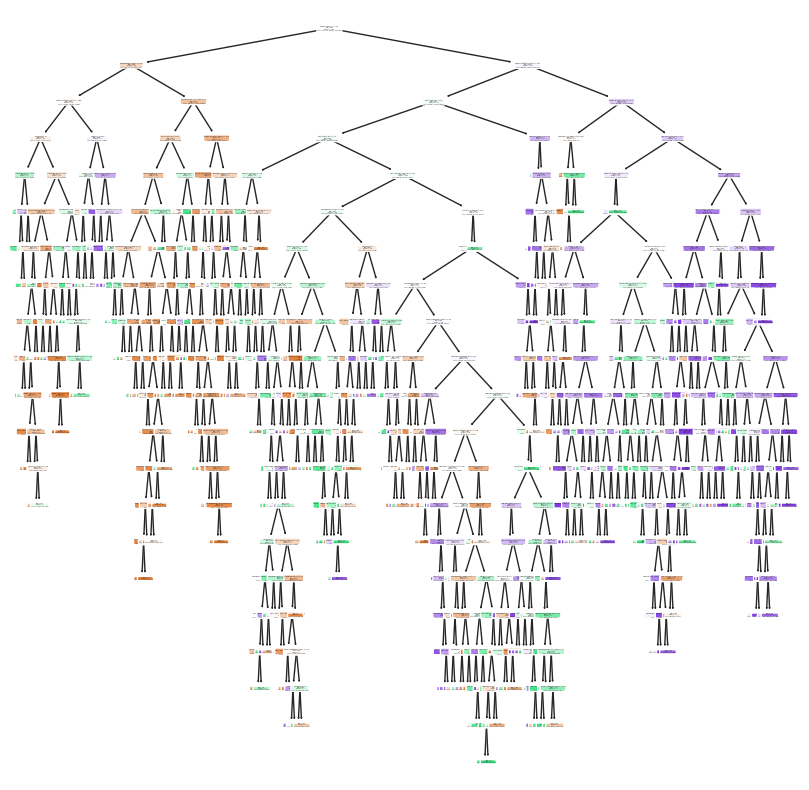

In [56]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Valitaan metsästä ensimmäinen puu (indeksi 0)
yksi_puu = rf.estimators_[0]

plt.figure(figsize=(10,10))
plot_tree(yksi_puu, 
          feature_names=X.columns, 
          filled=True, 
          rounded=True)
plt.show()

In [107]:
proba_xgbo_df['homeOddsdiff'] = proba_xgbo_df['pred_xgbo_H'] - proba_xgbo_df['HomeOdds']
proba_xgbo_df['awayOddsdiff'] = proba_xgbo_df['pred_xgbo_A'] - proba_xgbo_df['AwayOdds']
proba_xgbo_df['drawOddsdiff'] = proba_xgbo_df['pred_xgbo_D'] - proba_xgbo_df['DrawOdds']
std_dev_homediff = proba_xgbo_df['homeOddsdiff'].std()
std_dev_awaydiff = proba_xgbo_df['awayOddsdiff'].std()
std_dev_drawdiff = proba_xgbo_df['drawOddsdiff'].std()
print(std_dev_homediff)
print(std_dev_awaydiff)
print(std_dev_drawdiff)
proba_xgbo_df

0.06632492291690191
0.06609342451251604
0.032886572522634445


,pred_xgbo_H,pred_xgbo_D,pred_xgbo_A,HomeOdds,DrawOdds,AwayOdds,homeOddsdiff,awayOddsdiff,drawOddsdiff
0,0.562371,0.235174,0.202455,0.368517,0.287973,0.343510,0.193854,-0.141055,-0.052799
1,0.261436,0.247876,0.490688,0.213252,0.252432,0.534315,0.048183,-0.043627,-0.004556
2,0.795506,0.110411,0.094083,0.817383,0.126410,0.056207,-0.021876,0.037876,-0.016000
3,0.172364,0.182048,0.645588,0.131240,0.198889,0.669871,0.041124,-0.024282,-0.016841
4,0.189216,0.195975,0.614809,0.193189,0.230715,0.576096,-0.003973,0.038713,-0.034740
...,...,...,...,...,...,...,...,...,...
1158,0.361665,0.227698,0.410638,0.309101,0.256753,0.434146,0.052564,-0.023508,-0.029055
1159,0.152032,0.181906,0.666062,0.100538,0.162964,0.736498,0.051494,-0.070435,0.018941
1160,0.689273,0.179997,0.130730,0.721382,0.170040,0.108578,-0.032109,0.022153,0.009957
1161,0.682502,0.192919,0.124579,0.679776,0.168440,0.151784,0.002726,-0.027206,0.024479


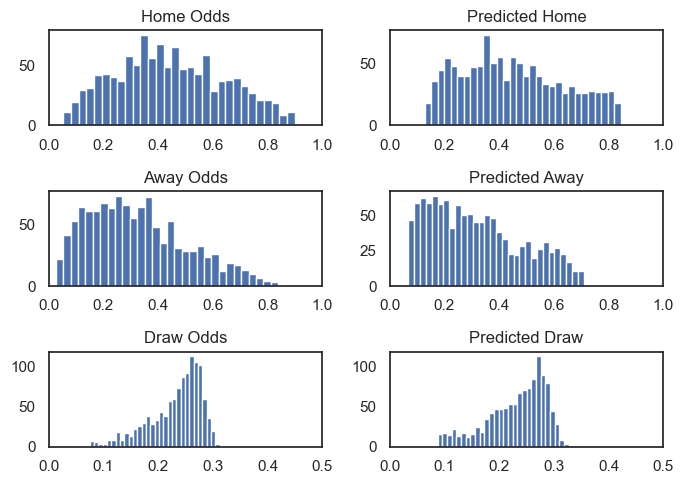

In [111]:
import matplotlib.pyplot as plt

# Data
pred_home = proba_xgbo_df['pred_xgbo_H'].dropna()
odds_home = proba_xgbo_df['HomeOdds'].dropna()

pred_away = proba_xgbo_df['pred_xgbo_A'].dropna()
odds_away = proba_xgbo_df['AwayOdds'].dropna()

pred_draw = proba_xgbo_df['pred_xgbo_D'].dropna()
odds_draw = proba_xgbo_df['DrawOdds'].dropna()

plt.figure(figsize=(7, 5))

# --- HOME ---
plt.subplot(3, 2, 2)
plt.hist(pred_home, bins=30)
plt.xlim(0, 1)
plt.title('Predicted Home')

plt.subplot(3, 2, 1)
plt.hist(odds_home, bins=30)
plt.xlim(0, 1)
plt.title('Home Odds')

# --- AWAY ---
plt.subplot(3, 2, 4)
plt.hist(pred_away, bins=30)
plt.xlim(0, 1)
plt.title('Predicted Away')

plt.subplot(3, 2, 3)
plt.hist(odds_away, bins=30)
plt.xlim(0, 1)
plt.title('Away Odds')

# --- DRAW ---
plt.subplot(3, 2, 6)
plt.hist(pred_draw, bins=30)
plt.xlim(0, 0.5)
plt.title('Predicted Draw')

plt.subplot(3, 2, 5)
plt.hist(odds_draw, bins=30)
plt.xlim(0, 0.5)
plt.title('Draw Odds')

plt.tight_layout()
plt.show()


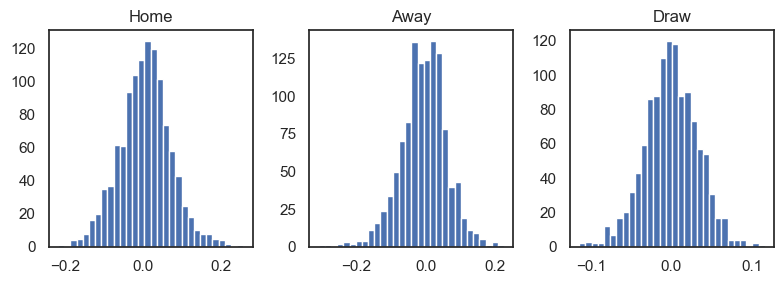

In [109]:
import matplotlib.pyplot as plt

homediff_xgbo = proba_xgbo_df['homeOddsdiff'].dropna()
awaydiff_xgbo = proba_xgbo_df['awayOddsdiff'].dropna()
drawdiff_xgbo = proba_xgbo_df['drawOddsdiff'].dropna()

fig, axes = plt.subplots(1, 3, figsize=(8, 3))

axes[0].hist(homediff_xgbo, bins=30)
axes[0].set_title('Home')

axes[1].hist(awaydiff_xgbo, bins=30)
axes[1].set_title('Away')

axes[2].hist(drawdiff_xgbo, bins=30)
axes[2].set_title('Draw')

plt.tight_layout()
plt.show()
